In [ ]:
!pip install opencv-python

In [ ]:
!pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 103.7 MB/s eta 0:00:00


In [ ]:
!pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.2/169.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.2 MB/s eta 0:00:00


In [ ]:
!pip install insightface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 16.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 96.9 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl size=1071484 sha256=8e7b11663b69d28c650c515250a53afad435f5b2f28f6fc66f56430e850b562d
  Stored in directory: /root/.cache/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface


In [ ]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.6/252.6 MB 5.4 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mtcnn.mtcnn import MTCNN
from deepface import DeepFace
from numpy.linalg import norm
import os
import pickle
from collections import defaultdict
from google.colab import drive
import time

26-02-20 07:11:43 - Directory /root/.deepface has been created
26-02-20 07:11:43 - Directory /root/.deepface/weights has been created


# MTCNN

(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

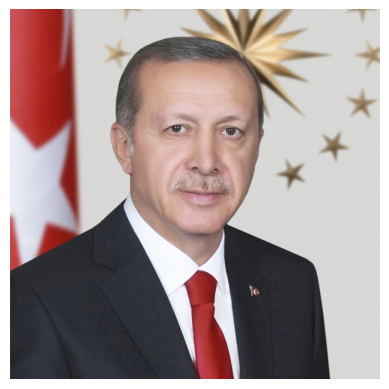

In [ ]:
img_path = "/content/imgi_134_recep-tayyip-1185.jpg"
img = cv2.imread(img_path)

# OpenCV loads BGR, convert to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")


In [ ]:
detector = MTCNN()

In [ ]:
results = detector.detect_faces(img_rgb)
print(f"Faces detected: {len(results)}")

Faces detected: 1


In [ ]:
print(results)

[{'box': [338, 136, 329, 467], 'confidence': np.float64(0.9994028806686401), 'keypoints': {'nose': [np.int64(535), np.int64(430)], 'mouth_right': [np.int64(577), np.int64(491)], 'right_eye': [np.int64(595), np.int64(331)], 'left_eye': [np.int64(450), np.int64(324)], 'mouth_left': [np.int64(452), np.int64(484)]}}]


(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

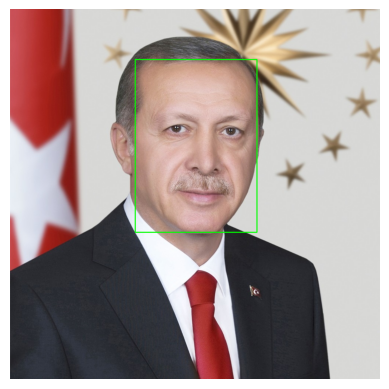

In [ ]:
img_boxes = img_rgb.copy()

for res in results:
    x, y, w, h = res['box']
    cv2.rectangle(img_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(img_boxes)
plt.axis("off")

# deepface embedder


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def extract_face(img_rgb, res):
    x, y, w, h = res['box']
    x, y = max(0, x), max(0, y)
    face = img_rgb[y:y+h, x:x+w]
    return face

In [ ]:
def l2_normalize(x):
    return x / (norm(x) + 1e-7)

In [ ]:
def get_embedding(face_img):
    try:
        embedding = DeepFace.represent(
            img_path=face_img,
            model_name="Facenet512",
            enforce_detection=False,
            detector_backend='skip'
        )[0]["embedding"]
        return np.array(embedding)
    except Exception as e:
        print(f"Error getting embedding: {e}")
        return None

In [ ]:
def get_largest_face(results):
    return max(results, key=lambda r: r['box'][2] * r['box'][3])

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/photo_facenet"
person_embeddings = defaultdict(list)

print("Building face database with DeepFace")
for person_name in os.listdir(DATASET_PATH):
    person_path = os.path.join(DATASET_PATH, person_name)

    if not os.path.isdir(person_path):
        continue

    print(f"Processing {person_name}")
    img_count = 0

    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            print(f"Could not read {img_name}")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = detector.detect_faces(img_rgb)

        if len(results) == 0:
            print(f"No face detected in {img_name}")
            continue

        face_img = extract_face(img_rgb, get_largest_face(results))

        embedding = get_embedding(face_img)

        if embedding is None:
            print(f"Could not get embedding for {img_name}")
            continue

        # Normalize
        embedding = l2_normalize(embedding)

        # Show info for first image
        if img_count == 0:
            print(f"Embedding shape: {embedding.shape}")
            print(f"First 10 values: {embedding[:10]}")
            print(f"Norm: {norm(embedding):.4f}")

        person_embeddings[person_name].append(embedding)
        img_count += 1

    print(f"Total images loaded: {img_count}")

Building face database with DeepFace
Processing Kassym-Jomart Tokayev
Embedding shape: (512,)
First 10 values: [ 0.0251006   0.00067673  0.01449278  0.03854918 -0.04665281 -0.01251279
 -0.06575128  0.04194075 -0.06315343  0.00955373]
Norm: 1.0000
Total images loaded: 21
Processing Recep Tayyip Erdogan
Embedding shape: (512,)
First 10 values: [ 0.12442218  0.08919252  0.01138378 -0.09961833 -0.00515717 -0.01855698
 -0.00546419  0.03363939 -0.00643593  0.04337886]
Norm: 1.0000
Total images loaded: 32
Processing Vladimir Putin
Embedding shape: (512,)
First 10 values: [ 0.04478772  0.06854592 -0.07067607 -0.04219584 -0.03380938  0.01213752
  0.05302773  0.03941852 -0.05277033  0.02506234]
Norm: 1.0000
Total images loaded: 24
Processing Shavkat Mirziyoyev
Embedding shape: (512,)
First 10 values: [ 0.09131302  0.0761048   0.0490477  -0.0347661   0.00934714 -0.01551078
 -0.01333753 -0.02432192  0.01404509 -0.04448176]
Norm: 1.0000
Total images loaded: 40


In [ ]:
db_embeddings = []
db_labels = []

print("Creating database from averaged embeddings")
for person, embs in person_embeddings.items():
    print(f"\n{person}: {len(embs)} faces")


    if len(embs) > 1:
        sim = np.dot(embs[0], embs[1])
        print(f"Similarity between first two images: {sim:.4f}")

    # Average and normalize
    mean_emb = np.mean(embs, axis=0)
    mean_emb = l2_normalize(mean_emb)

    print(f"Mean embedding (first 10): {mean_emb[:10]}")

    db_embeddings.append(mean_emb)
    db_labels.append(person)

db_embeddings = np.array(db_embeddings)
db_labels = np.array(db_labels)

Creating database from averaged embeddings

Kassym-Jomart Tokayev: 21 faces
Similarity between first two images: 0.8958
Mean embedding (first 10): [ 0.04637395  0.00670996  0.0167971   0.04678917 -0.02603294 -0.01209819
 -0.07598913  0.04072463 -0.06121845  0.00102796]

Recep Tayyip Erdogan: 32 faces
Similarity between first two images: 0.8600
Mean embedding (first 10): [ 0.13162373  0.07208983  0.02909236 -0.07869298 -0.00367049  0.00060413
  0.0076111   0.00395262 -0.03105323  0.04738202]

Vladimir Putin: 24 faces
Similarity between first two images: 0.8106
Mean embedding (first 10): [ 0.06866011  0.02743926 -0.06759526 -0.01053111 -0.02276504  0.0383005
  0.04301541  0.07416822 -0.11264348  0.00051999]

Shavkat Mirziyoyev: 40 faces
Similarity between first two images: 0.8342
Mean embedding (first 10): [ 0.08773241  0.07675922  0.01705374 -0.04476322  0.00258569 -0.00907232
 -0.05143262 -0.00857431  0.01624809 -0.02566797]


In [ ]:
print("Checking embedding diversity between people:")
for i in range(len(db_embeddings)):
    for j in range(i+1, len(db_embeddings)):
        sim = np.dot(db_embeddings[i], db_embeddings[j])
        print(f"{db_labels[i]} vs {db_labels[j]}: {sim:.4f}")

Checking embedding diversity between people:
Kassym-Jomart Tokayev vs Recep Tayyip Erdogan: 0.0154
Kassym-Jomart Tokayev vs Vladimir Putin: 0.2855
Kassym-Jomart Tokayev vs Shavkat Mirziyoyev: 0.3186
Recep Tayyip Erdogan vs Vladimir Putin: 0.0156
Recep Tayyip Erdogan vs Shavkat Mirziyoyev: 0.3022
Vladimir Putin vs Shavkat Mirziyoyev: 0.3185


In [ ]:
with open("face_db_deepface.pkl", "wb") as f:
    pickle.dump((db_embeddings, db_labels), f)

print(f"Database saved with shape: {db_embeddings.shape}")

Database saved with shape: (4, 512)


#checking boxes

In [ ]:
def show_boxes(img_rgb, results):
    img_copy = img_rgb.copy()
    for res in results:
        x, y, w, h = res['box']
        x, y = max(0, x), max(0, y)
        cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)
    plt.figure(figsize=(5, 5))
    plt.imshow(img_copy)
    plt.axis("off")

In [ ]:
def show_face(face_img):
    plt.figure(figsize=(3, 3))
    plt.imshow(face_img)
    plt.axis("off")

In [ ]:
MAX_IMAGES_PER_PERSON = 3

for person_name in os.listdir(DATASET_PATH):
    person_path = os.path.join(DATASET_PATH, person_name)

    if not os.path.isdir(person_path):
        continue

    print(f"Person: {person_name}")

    count = 0
    for img_name in os.listdir(person_path):
        if count >= MAX_IMAGES_PER_PERSON:
            break

        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = detector.detect_faces(img_rgb)

        if len(results) == 0:
            print("No face detected")
            continue

        show_boxes(img_rgb, results)

        face_img = extract_face(img_rgb, get_largest_face(results))
        show_face(face_img)

        count += 1

# recognizing

In [ ]:
with open("face_db_deepface.pkl", "rb") as f:
    db_embeddings, db_labels = pickle.load(f)

print(db_embeddings.shape, db_labels.shape)

(4, 512) (4,)


In [ ]:
db_labels

array(['Kassym-Jomart Tokayev', 'Recep Tayyip Erdogan', 'Vladimir Putin',
       'Shavkat Mirziyoyev'], dtype='<U21')

In [ ]:
db_embeddings

array([[ 0.04637395,  0.00670996,  0.0167971 , ..., -0.04329366,
        -0.03728888,  0.04761316],
       [ 0.13162373,  0.07208983,  0.02909236, ..., -0.03128975,
        -0.02342469, -0.03136366],
       [ 0.06866011,  0.02743926, -0.06759526, ..., -0.0488683 ,
        -0.0567706 ,  0.01786158],
       [ 0.08773241,  0.07675922,  0.01705374, ..., -0.06278977,
        -0.0150684 ,  0.01788997]])

In [ ]:
def identify_face(face_embedding, db_embeddings, db_labels, threshold=0.6):

    similarities = np.dot(db_embeddings, face_embedding)

    best_idx = np.argmax(similarities)
    best_score = similarities[best_idx]

    print(f"Similarities:")
    for label, sim in zip(db_labels, similarities):
        print(f"{label}: {sim:.4f}")

    if best_score >= threshold:
        return db_labels[best_idx], best_score
    else:
        return "Unknown", best_score

In [ ]:
test_img_path = "/content/imgi_134_recep-tayyip-1185.jpg"
img = cv2.imread(test_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

results = detector.detect_faces(img_rgb)
img_out = img_rgb.copy()

In [ ]:
print(f"Detected {len(results)} face")

Detected 1 face


Face 1
Similarities:
Kassym-Jomart Tokayev: 0.0423
Recep Tayyip Erdogan: 0.8338
Vladimir Putin: 0.0212
Shavkat Mirziyoyev: 0.3585


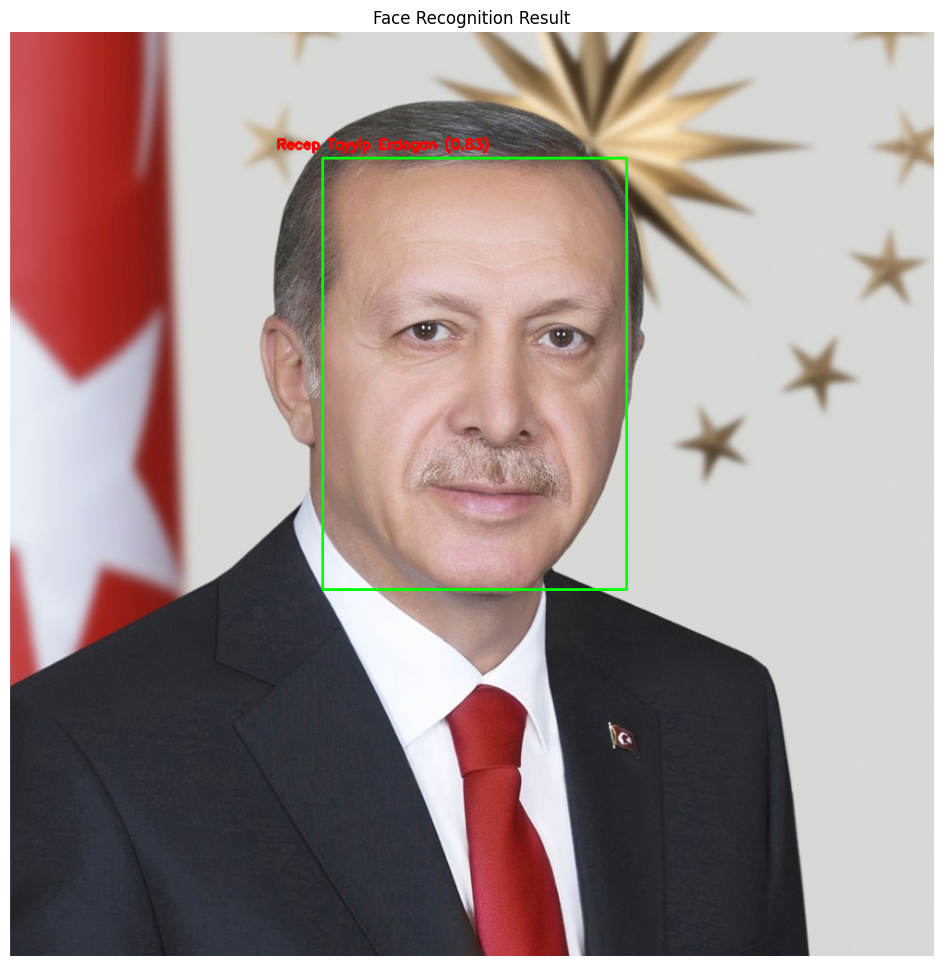

In [ ]:
for idx, res in enumerate(results):
    print(f"Face {idx+1}")
    x, y, w, h = res['box']
    x, y = max(0, x), max(0, y)

    face_img = extract_face(img_rgb, res)

    # Get embedding
    embedding = get_embedding(face_img)

    if embedding is None:
        print("Could not get embedding")
        continue

    embedding = l2_normalize(embedding)

    # Identify
    name, score = identify_face(embedding, db_embeddings, db_labels, threshold=0.6)

    label = f"{name} ({score:.2f})"

    # Draw on image
    cv2.rectangle(img_out, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(img_out, label, (x - 50, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

# Display result
plt.figure(figsize=(12, 12))
plt.imshow(img_out)
plt.axis("off")
plt.title("Face Recognition Result")
plt.show()

# testing all images

In [ ]:
path = "/content/photos"

for photo in os.listdir(path):

    test_img_path = os.path.join(path, photo)
    print(test_img_path)

    img = cv2.imread(test_img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = detector.detect_faces(img_rgb)
    img_out = img_rgb.copy()

    print(f"Detected {len(results)} face")

    for idx, res in enumerate(results):
        print(f"Face {idx+1}")
        x, y, w, h = res['box']
        x, y = max(0, x), max(0, y)

        face_img = extract_face(img_rgb, res)

        # Get embedding
        embedding = get_embedding(face_img)

        if embedding is None:
            print("Could not get embedding")
            continue

        embedding = l2_normalize(embedding)

        # Identify
        name, score = identify_face(embedding, db_embeddings, db_labels, threshold=0.6)

        label = f"{name} ({score:.2f})"

        # Draw on image
        cv2.rectangle(img_out, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(img_out, label, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

    # Display result
    plt.figure(figsize=(12, 12))
    plt.imshow(img_out)
    plt.axis("off")
    plt.title("Face Recognition Result")
    plt.show()

# insight face

In [ ]:
import insightface
print(f"InsightFace version: {insightface.__version__}")

InsightFace version: 0.7.3


In [ ]:
import insightface
from insightface.app import FaceAnalysis

In [ ]:
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

print("InsightFace initialized successfully!")

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 83882.84KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

Detected 1 face(s)

Face information:

--- Face 1 ---
Bounding box: [1203.8507  346.7874 1909.8497 1296.4309]
Embedding shape: (512,)
Embedding (first 10 values): [-0.7528707  -0.4215626  -0.7038126  -2.0782247  -0.39789897 -0.788034
 -0.22737616 -0.11392761 -0.18138567  1.7017843 ]
Detection confidence: 0.6994
Embedding mean: -0.007893
Embedding std: 1.003654
Embedding min: -3.046805
Embedding max: 2.683942


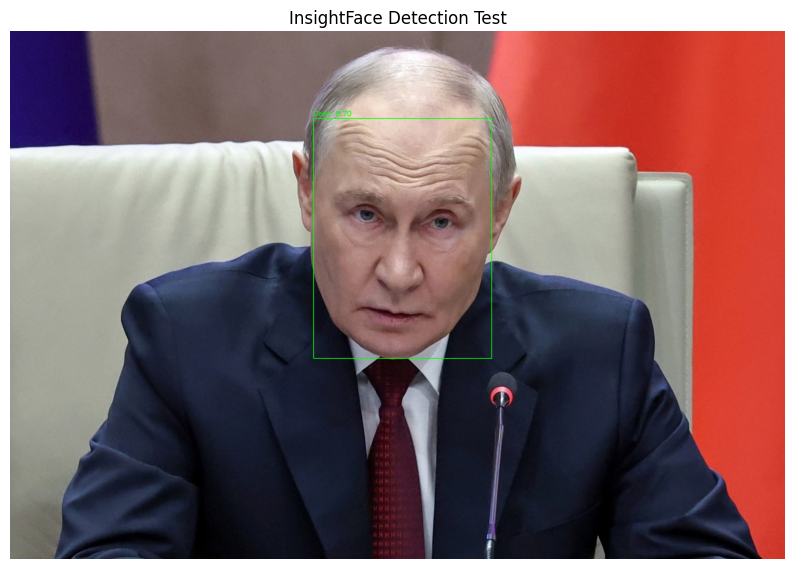

In [ ]:
test_img_path = "/content/drive/MyDrive/photo_facenet/Vladimir Putin/imgi_173_putin-2-epa-gmh-251126_1764164413946_hpMain.jpg"

# Read image
img = cv2.imread(test_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Detect and analyze faces
faces = app.get(img_rgb)

print(f"Detected {len(faces)} face(s)")
print("\nFace information:")

for idx, face in enumerate(faces):
    print(f"\n--- Face {idx+1} ---")
    print(f"Bounding box: {face.bbox}")
    print(f"Embedding shape: {face.embedding.shape}")  # Should be (512,) for buffalo_l
    print(f"Embedding (first 10 values): {face.embedding[:10]}")
    print(f"Detection confidence: {face.det_score:.4f}")

    # Check if embeddings are different (not all same values)
    print(f"Embedding mean: {face.embedding.mean():.6f}")
    print(f"Embedding std: {face.embedding.std():.6f}")
    print(f"Embedding min: {face.embedding.min():.6f}")
    print(f"Embedding max: {face.embedding.max():.6f}")

# Visualize detection
img_viz = img_rgb.copy()
for face in faces:
    bbox = face.bbox.astype(int)
    cv2.rectangle(img_viz, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
    cv2.putText(img_viz, f"Conf: {face.det_score:.2f}",
                (bbox[0], bbox[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(img_viz)
plt.axis('off')
plt.title("InsightFace Detection Test")
plt.show()

In [ ]:
test_images = {
    "Putin": "/content/drive/MyDrive/photo_facenet/Vladimir Putin/imgi_173_putin-2-epa-gmh-251126_1764164413946_hpMain.jpg",
    "Erdogan": "/content/drive/MyDrive/photo_facenet/Recep Tayyip Erdogan/imgi_167_Erdogan_custom-5d8bca9e7a331d6a311818a5d552d864ddba3af5.jpg",
}

embeddings_test = {}

for name, path in test_images.items():
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = app.get(img_rgb)

    if len(faces) > 0:
        embeddings_test[name] = faces[0].embedding
        print(f"{name} - Embedding (first 10): {faces[0].embedding[:10]}")

# Compare embeddings
if len(embeddings_test) == 2:
    names = list(embeddings_test.keys())
    emb1 = embeddings_test[names[0]]
    emb2 = embeddings_test[names[1]]

    # Cosine similarity
    from numpy.linalg import norm
    def cosine_similarity(a, b):
        return np.dot(a, b) / (norm(a) * norm(b))

    similarity = cosine_similarity(emb1, emb2)
    print(f"\nSimilarity between {names[0]} and {names[1]}: {similarity:.4f}")
    print("Expected: < 0.6 (different people)")

    if similarity < 0.6:
        print("Embeddings are correctly different!")
    else:
        print("Warning: Embeddings are too similar!")

Putin - Embedding (first 10): [-0.7528707  -0.4215626  -0.7038126  -2.0782247  -0.39789897 -0.788034
 -0.22737616 -0.11392761 -0.18138567  1.7017843 ]
Erdogan - Embedding (first 10): [ 1.5909714   1.0377667   0.53327554  0.44435754  0.23512475  1.4940536
 -0.38672084  1.5735269   0.33504552  2.0100303 ]

Similarity between Putin and Erdogan: 0.0389
Expected: < 0.6 (different people)
Embeddings are correctly different!


In [ ]:
start = time.time()
insightface_faces = app.get(img_rgb)
insightface_time = time.time() - start


start = time.time()
mtcnn_faces = detector.detect_faces(img_rgb)
mtcnn_time = time.time() - start


print("DETECTION COMPARISON:")
print(f"\nInsightFace:")
print(f"Faces detected: {len(insightface_faces)}")
print(f"Time: {insightface_time:.3f}s")

print(f"\nMTCNN:")
print(f"Faces detected: {len(mtcnn_faces)}")
print(f"Time: {mtcnn_time:.3f}s")

print(f"Speed difference: InsightFace is {mtcnn_time/insightface_time:.2f}x faster")

DETECTION COMPARISON:

InsightFace:
Faces detected: 1
Time: 0.056s

MTCNN:
Faces detected: 1
Time: 17.761s
Speed difference: InsightFace is 316.21x faster


# building parallell system

In [ ]:
class InsightFaceSystem:
    def __init__(self, model_name='buffalo_l'):
        """Initialize InsightFace system"""
        print(f"Initializing InsightFace ({model_name})...")
        self.app = FaceAnalysis(name=model_name, providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
        self.app.prepare(ctx_id=0, det_size=(640, 640))
        print("InsightFace ready!")

    def detect_faces(self, img_rgb):
        """
        Detect faces in image
        Returns: list of face objects
        """
        return self.app.get(img_rgb)

    def get_embedding(self, face_obj):
        """
        Get embedding from face object
        face_obj: InsightFace face object
        Returns: normalized embedding
        """
        embedding = face_obj.embedding
        # L2 normalize
        embedding = embedding / (norm(embedding) + 1e-7)
        return embedding

    def build_database(self, dataset_path, save_path="face_db_insightface.pkl"):
        """
        Build face database from folder structure
        dataset_path: path to folder with person subfolders
        """
        print(f"\n{'='*50}")
        print("Building InsightFace Database...")
        print(f"{'='*50}")

        person_embeddings = defaultdict(list)

        for person_name in os.listdir(dataset_path):
            person_path = os.path.join(dataset_path, person_name)

            if not os.path.isdir(person_path):
                continue

            print(f"\nProcessing {person_name}...")
            img_count = 0

            for img_name in os.listdir(person_path):
                img_path = os.path.join(person_path, img_name)
                img = cv2.imread(img_path)

                if img is None:
                    continue

                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                faces = self.detect_faces(img_rgb)

                if len(faces) == 0:
                    continue

                # Use largest face
                largest_face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0]) * (f.bbox[3]-f.bbox[1]))
                embedding = self.get_embedding(largest_face)

                person_embeddings[person_name].append(embedding)
                img_count += 1

            print(f"Loaded {img_count} images")

        # Create database
        db_embeddings = []
        db_labels = []

        print(f"\n{'='*50}")
        print("Creating averaged embeddings...")
        for person, embs in person_embeddings.items():
            mean_emb = np.mean(embs, axis=0)
            mean_emb = mean_emb / (norm(mean_emb) + 1e-7)

            db_embeddings.append(mean_emb)
            db_labels.append(person)
            print(f"{person}: {len(embs)} faces")

        db_embeddings = np.array(db_embeddings)
        db_labels = np.array(db_labels)

        # Check diversity
        print(f"\nChecking diversity:")
        for i in range(len(db_embeddings)):
            for j in range(i+1, len(db_embeddings)):
                sim = np.dot(db_embeddings[i], db_embeddings[j])
                print(f"  {db_labels[i]} vs {db_labels[j]}: {sim:.4f}")

        # Save
        with open(save_path, "wb") as f:
            pickle.dump((db_embeddings, db_labels), f)

        print(f"\nDatabase saved: {save_path}")
        print(f"Shape: {db_embeddings.shape}")

        return db_embeddings, db_labels

    def identify_face(self, embedding, db_embeddings, db_labels, threshold=0.6, distance_metric='cosine'):
        """
        Identify face using embedding
        distance_metric: 'cosine' or 'euclidean'
        """
        if distance_metric == 'cosine':
            similarities = np.dot(db_embeddings, embedding)
            best_idx = np.argmax(similarities)
            best_score = similarities[best_idx]

            if best_score >= threshold:
                return db_labels[best_idx], best_score
            else:
                return "Unknown", best_score

        elif distance_metric == 'euclidean':
            distances = np.linalg.norm(db_embeddings - embedding, axis=1)
            best_idx = np.argmin(distances)
            best_distance = distances[best_idx]

            # Lower distance = more similar
            # Typical threshold for euclidean: 0.6-1.0
            if best_distance <= threshold:
                return db_labels[best_idx], best_distance
            else:
                return "Unknown", best_distance

    def recognize_image(self, img_path, db_embeddings, db_labels, threshold=0.6, distance_metric='cosine', show_result=True):
        """
        Recognize all faces in an image
        """
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        start_time = time.time()
        faces = self.detect_faces(img_rgb)
        detection_time = time.time() - start_time

        results = []
        img_out = img_rgb.copy()

        for face in faces:
            bbox = face.bbox.astype(int)

            # Get embedding
            embedding = self.get_embedding(face)

            # Identify
            name, score = self.identify_face(embedding, db_embeddings, db_labels, threshold, distance_metric)

            results.append({
                'name': name,
                'score': score,
                'bbox': bbox,
                'confidence': face.det_score
            })

            # Draw
            color = (0, 255, 0) if name != "Unknown" else (0, 0, 255)
            cv2.rectangle(img_out, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)

            label = f"{name} ({score:.2f})"
            cv2.putText(img_out, label, (bbox[0], bbox[1]-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

        total_time = time.time() - start_time

        if show_result:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(12, 12))
            plt.imshow(img_out)
            plt.axis('off')
            plt.title(f"InsightFace - {len(faces)} face(s) - {total_time:.3f}s")
            plt.show()

        return results, img_out, detection_time, total_time


# Initialize InsightFace system
insightface_system = InsightFaceSystem(model_name='buffalo_l')

Initializing InsightFace (buffalo_l)...
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionPr

In [ ]:
class DeepFaceSystem:
    def __init__(self, model_name='Facenet512'):
        """Initialize DeepFace system"""
        print(f"Initializing DeepFace ({model_name})...")
        self.detector = MTCNN()
        self.model_name = model_name
        print("DeepFace ready!")

    def detect_faces(self, img_rgb):
        """
        Detect faces using MTCNN
        Returns: list of detection results
        """
        return self.detector.detect_faces(img_rgb)

    def extract_face(self, img_rgb, detection):
        """Extract face from detection"""
        x, y, w, h = detection['box']
        x, y = max(0, x), max(0, y)
        face = img_rgb[y:y+h, x:x+w]
        return face

    def get_embedding(self, face_img):
        """Get embedding using DeepFace"""
        try:
            embedding = DeepFace.represent(
                img_path=face_img,
                model_name=self.model_name,
                enforce_detection=False,
                detector_backend='skip'
            )[0]["embedding"]
            embedding = np.array(embedding)
            # L2 normalize
            embedding = embedding / (norm(embedding) + 1e-7)
            return embedding
        except:
            return None

    def build_database(self, dataset_path, save_path="face_db_deepface.pkl"):
        """Build face database"""
        print(f"\n{'='*50}")
        print("Building DeepFace Database...")
        print(f"{'='*50}")

        person_embeddings = defaultdict(list)

        for person_name in os.listdir(dataset_path):
            person_path = os.path.join(dataset_path, person_name)

            if not os.path.isdir(person_path):
                continue

            print(f"\nProcessing {person_name}...")
            img_count = 0

            for img_name in os.listdir(person_path):
                img_path = os.path.join(person_path, img_name)
                img = cv2.imread(img_path)

                if img is None:
                    continue

                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                faces = self.detect_faces(img_rgb)

                if len(faces) == 0:
                    continue

                # Use largest face
                largest_face = max(faces, key=lambda f: f['box'][2] * f['box'][3])
                face_img = self.extract_face(img_rgb, largest_face)
                embedding = self.get_embedding(face_img)

                if embedding is None:
                    continue

                person_embeddings[person_name].append(embedding)
                img_count += 1

            print(f"Loaded {img_count} images")

        # Create database
        db_embeddings = []
        db_labels = []

        print(f"\n{'='*50}")
        print("Creating averaged embeddings...")
        for person, embs in person_embeddings.items():
            mean_emb = np.mean(embs, axis=0)
            mean_emb = mean_emb / (norm(mean_emb) + 1e-7)

            db_embeddings.append(mean_emb)
            db_labels.append(person)
            print(f"{person}: {len(embs)} faces")

        db_embeddings = np.array(db_embeddings)
        db_labels = np.array(db_labels)

        # Check diversity
        print(f"\nChecking diversity:")
        for i in range(len(db_embeddings)):
            for j in range(i+1, len(db_embeddings)):
                sim = np.dot(db_embeddings[i], db_embeddings[j])
                print(f"  {db_labels[i]} vs {db_labels[j]}: {sim:.4f}")

        # Save
        with open(save_path, "wb") as f:
            pickle.dump((db_embeddings, db_labels), f)

        print(f"\nDatabase saved: {save_path}")
        print(f"Shape: {db_embeddings.shape}")

        return db_embeddings, db_labels

    def identify_face(self, embedding, db_embeddings, db_labels, threshold=0.6, distance_metric='cosine'):
        """Identify face - same as InsightFace"""
        if distance_metric == 'cosine':
            similarities = np.dot(db_embeddings, embedding)
            best_idx = np.argmax(similarities)
            best_score = similarities[best_idx]

            if best_score >= threshold:
                return db_labels[best_idx], best_score
            else:
                return "Unknown", best_score

        elif distance_metric == 'euclidean':
            distances = np.linalg.norm(db_embeddings - embedding, axis=1)
            best_idx = np.argmin(distances)
            best_distance = distances[best_idx]

            if best_distance <= threshold:
                return db_labels[best_idx], best_distance
            else:
                return "Unknown", best_distance

    def recognize_image(self, img_path, db_embeddings, db_labels, threshold=0.6, distance_metric='cosine', show_result=True):
        """Recognize all faces in image"""
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        start_time = time.time()
        faces = self.detect_faces(img_rgb)
        detection_time = time.time() - start_time

        results = []
        img_out = img_rgb.copy()

        for detection in faces:
            x, y, w, h = detection['box']
            x, y = max(0, x), max(0, y)

            face_img = self.extract_face(img_rgb, detection)
            embedding = self.get_embedding(face_img)

            if embedding is None:
                continue

            name, score = self.identify_face(embedding, db_embeddings, db_labels, threshold, distance_metric)

            results.append({
                'name': name,
                'score': score,
                'bbox': (x, y, x+w, y+h),
                'confidence': detection['confidence']
            })

            # Draw
            color = (0, 255, 0) if name != "Unknown" else (0, 0, 255)
            cv2.rectangle(img_out, (x, y), (x+w, y+h), color, 2)

            label = f"{name} ({score:.2f})"
            cv2.putText(img_out, label, (x, y-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

        total_time = time.time() - start_time

        if show_result:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(12, 12))
            plt.imshow(img_out)
            plt.axis('off')
            plt.title(f"DeepFace - {len(faces)} face(s) - {total_time:.3f}s")
            plt.show()

        return results, img_out, detection_time, total_time


# Initialize DeepFace system
deepface_system = DeepFaceSystem(model_name='Facenet512')

Initializing DeepFace (Facenet512)...
DeepFace ready!


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/photo_facenet"

# Build InsightFace database
print("="*70)
print("BUILDING INSIGHTFACE DATABASE")
print("="*70)
insightface_db_emb, insightface_db_labels = insightface_system.build_database(
    DATASET_PATH,
    save_path="face_db_insightface.pkl"
)

print("\n\n")

# Build DeepFace database
print("="*70)
print("BUILDING DEEPFACE DATABASE")
print("="*70)
deepface_db_emb, deepface_db_labels = deepface_system.build_database(
    DATASET_PATH,
    save_path="face_db_deepface.pkl"
)

print("\n\n")
print("="*70)
print("BOTH DATABASES READY!")
print("="*70)

BUILDING INSIGHTFACE DATABASE

Building InsightFace Database...

Processing Kassym-Jomart Tokayev...
Loaded 21 images

Processing Recep Tayyip Erdogan...
Loaded 32 images

Processing Vladimir Putin...
Loaded 24 images

Processing Shavkat Mirziyoyev...
Loaded 40 images

Creating averaged embeddings...
Kassym-Jomart Tokayev: 21 faces
Recep Tayyip Erdogan: 32 faces
Vladimir Putin: 24 faces
Shavkat Mirziyoyev: 40 faces

Checking diversity:
  Kassym-Jomart Tokayev vs Recep Tayyip Erdogan: 0.0311
  Kassym-Jomart Tokayev vs Vladimir Putin: 0.0463
  Kassym-Jomart Tokayev vs Shavkat Mirziyoyev: 0.1019
  Recep Tayyip Erdogan vs Vladimir Putin: -0.0386
  Recep Tayyip Erdogan vs Shavkat Mirziyoyev: 0.1030
  Vladimir Putin vs Shavkat Mirziyoyev: 0.0525

Database saved: face_db_insightface.pkl
Shape: (4, 512)



BUILDING DEEPFACE DATABASE

Building DeepFace Database...

Processing Kassym-Jomart Tokayev...
Loaded 21 images

Processing Recep Tayyip Erdogan...
Loaded 32 images

Processing Vladimir Puti

TESTING INSIGHTFACE


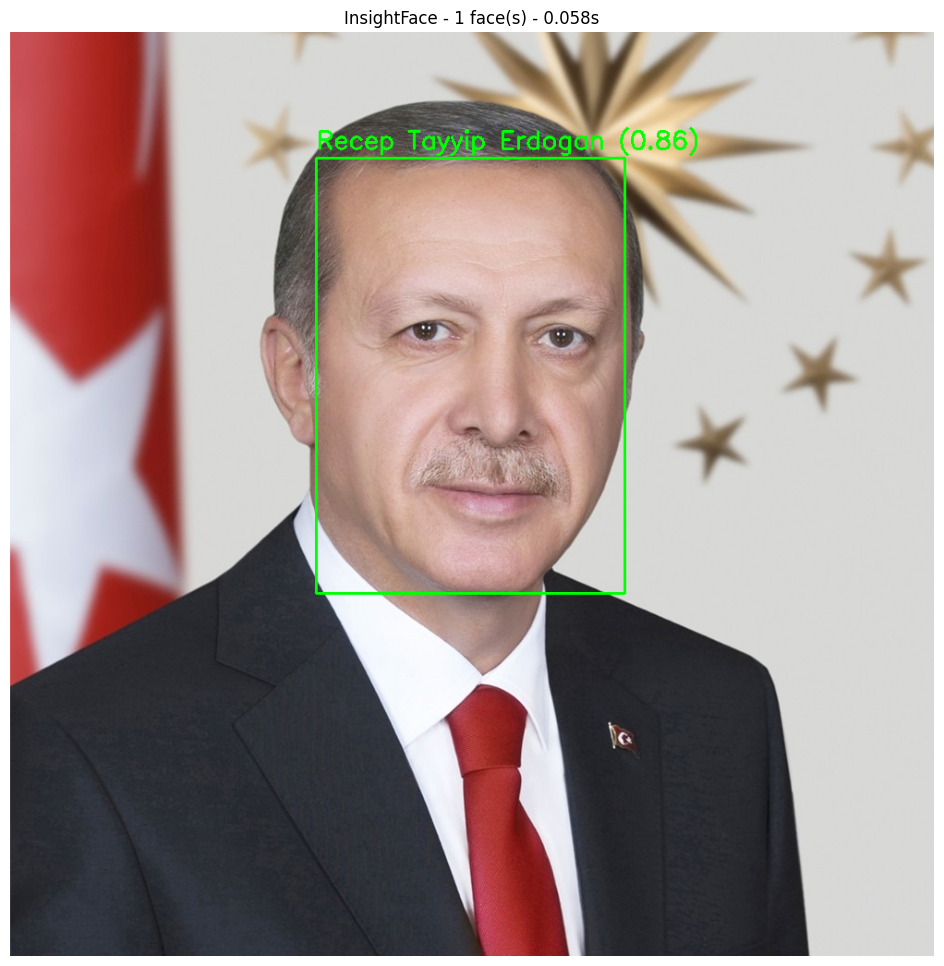




TESTING DEEPFACE


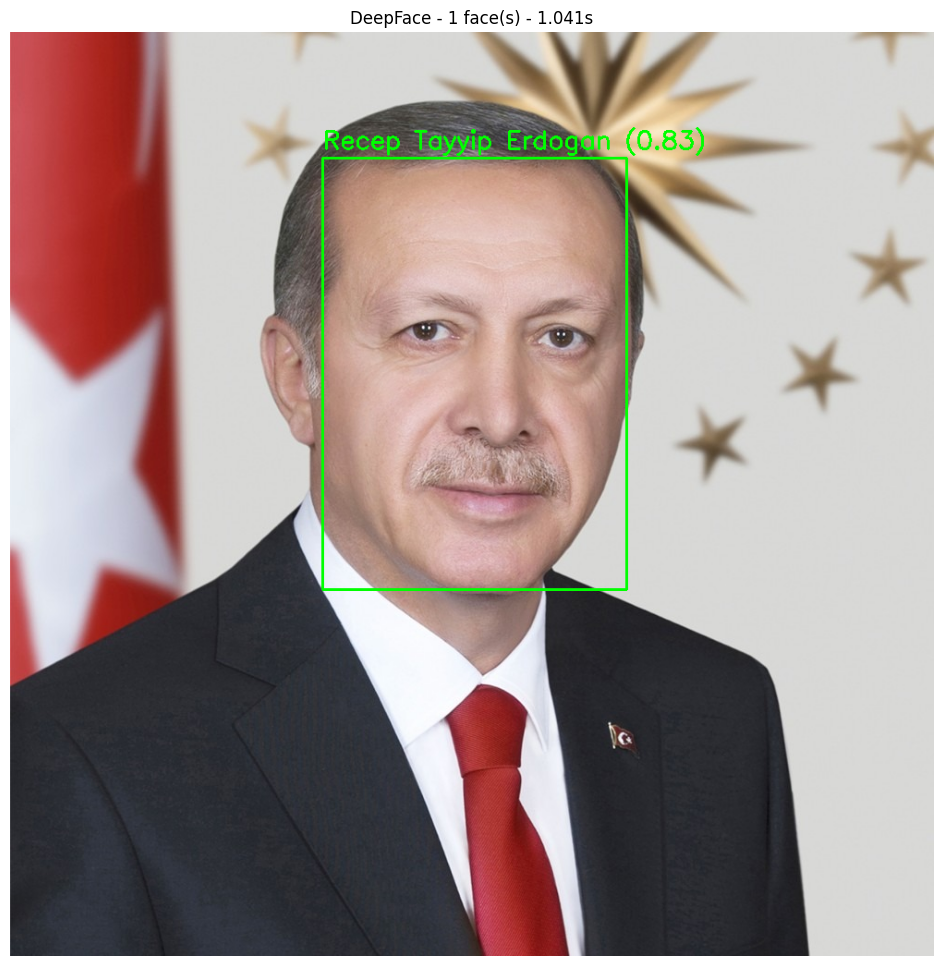




QUICK COMPARISON
InsightFace: 0.058s
DeepFace: 1.041s
Speed: InsightFace is 17.9x faster


In [ ]:
test_img = "/content/imgi_134_recep-tayyip-1185.jpg"

print("="*70)
print("TESTING INSIGHTFACE")
print("="*70)
insightface_results, _, _, insightface_time = insightface_system.recognize_image(
    test_img,
    insightface_db_emb,
    insightface_db_labels,
    threshold=0.6,
    distance_metric='cosine'
)

print("\n\n")

print("="*70)
print("TESTING DEEPFACE")
print("="*70)
deepface_results, _, _, deepface_time = deepface_system.recognize_image(
    test_img,
    deepface_db_emb,
    deepface_db_labels,
    threshold=0.6,
    distance_metric='cosine'
)

print("\n\n")
print("="*70)
print("QUICK COMPARISON")
print("="*70)
print(f"InsightFace: {insightface_time:.3f}s")
print(f"DeepFace: {deepface_time:.3f}s")
print(f"Speed: InsightFace is {deepface_time/insightface_time:.1f}x faster")

# Building test framework

In [ ]:
import os
import shutil

# Create test structure
TEST_BASE = "/content/test_data"
os.makedirs(TEST_BASE, exist_ok=True)

# We'll organize tests into categories
test_structure = {
    "single_face": [],      # Single person, clear image
    "multiple_faces": [],   # Group photos
    "unknown_faces": [],    # People not in database
    "challenging": []       # Bad lighting, angles, etc.
}

print("Test data structure created:")
print(f"Base path: {TEST_BASE}")
print("\nCategories:")
for category in test_structure.keys():
    print(f"- {category}")

Test data structure created:
Base path: /content/test_data

Categories:
- single_face
- multiple_faces
- unknown_faces
- challenging


In [ ]:
import random

DATASET_PATH = "/content/drive/MyDrive/photo_facenet"

# Sample test images
test_images = {
    "single_face": [],
    "multiple_faces": [],  # You'll need to add group photos manually
    "unknown_faces": []    # We'll need some unknown faces
}

# Sample 2 images per person for single face tests
print("Sampling test images...")
for person_name in os.listdir(DATASET_PATH):
    person_path = os.path.join(DATASET_PATH, person_name)

    if not os.path.isdir(person_path):
        continue

    images = [f for f in os.listdir(person_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

    if len(images) >= 2:
        # Take 2 random images
        sampled = random.sample(images, min(2, len(images)))
        for img in sampled:
            test_images["single_face"].append({
                "path": os.path.join(person_path, img),
                "true_label": person_name,
                "category": "single_face"
            })

print(f"Prepared {len(test_images['single_face'])} single face test images")

Sampling test images...
Prepared 8 single face test images


In [ ]:
d_path = '/content/drive/MyDrive/extra_faces'

for person_name in os.listdir(d_path):
    person_path = os.path.join(d_path, person_name)

    if not os.path.isdir(person_path):
        continue

    images = [f for f in os.listdir(person_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

    if len(images) >= 2:
        # Take 2 random images
        sampled = random.sample(images, min(2, len(images)))
        for img in sampled:
            test_images["multiple_faces"].append({
                "path": os.path.join(person_path, img),
                "true_label": person_name.split(','),
                "category": "multiple_faces"
            })

print(f"Prepared {len(test_images['multiple_faces'])} multiple faces test images")

Prepared 8 multiple faces test images


In [ ]:
print(f"Total test images: {sum(len(v) for v in test_images.values())}")

Total test images: 16


In [ ]:
class FaceRecognitionEvaluator:
    def __init__(self):
        self.reset()

    def reset(self):
        """Reset all metrics"""
        self.results = {
            'correct': 0,
            'incorrect': 0,
            'false_positive': 0,  # Unknown labeled as known
            'false_negative': 0,  # Known labeled as unknown
            'total': 0,
            'detection_times': [],
            'total_times': [],
            'detailed_results': []
        }

    def add_result(self, true_label, predicted_label, score, detection_time, total_time, test_type="single"):
        """Add a single test result"""
        self.results['total'] += 1
        self.results['detection_times'].append(detection_time)
        self.results['total_times'].append(total_time)

        # Record detailed result
        result_detail = {
            'true_label': true_label,
            'predicted_label': predicted_label,
            'score': score,
            'detection_time': detection_time,
            'total_time': total_time,
            'test_type': test_type
        }

        # Evaluate correctness
        if true_label == "Unknown":
            if predicted_label == "Unknown":
                result_detail['status'] = 'correct'
                self.results['correct'] += 1
            else:
                result_detail['status'] = 'false_positive'
                self.results['false_positive'] += 1
        else:
            if predicted_label == true_label:
                result_detail['status'] = 'correct'
                self.results['correct'] += 1
            elif predicted_label == "Unknown":
                result_detail['status'] = 'false_negative'
                self.results['false_negative'] += 1
            else:
                result_detail['status'] = 'incorrect'
                self.results['incorrect'] += 1

        self.results['detailed_results'].append(result_detail)

    def calculate_metrics(self):
        """Calculate summary metrics"""
        total = self.results['total']
        if total == 0:
            return None

        metrics = {
            'accuracy': self.results['correct'] / total,
            'false_positive_rate': self.results['false_positive'] / total,
            'false_negative_rate': self.results['false_negative'] / total,
            'avg_detection_time': np.mean(self.results['detection_times']),
            'avg_total_time': np.mean(self.results['total_times']),
            'total_tests': total
        }

        return metrics

    def print_summary(self, system_name):
        """Print evaluation summary"""
        metrics = self.calculate_metrics()

        if metrics is None:
            print("No results to display")
            return

        print(f"\n{'='*70}")
        print(f"{system_name} - EVALUATION SUMMARY")
        print(f"{'='*70}")
        print(f"Total Tests: {metrics['total_tests']}")
        print(f"\nAccuracy Metrics:")
        print(f"Accuracy: {metrics['accuracy']*100:.2f}%")
        print(f"False Positive Rate: {metrics['false_positive_rate']*100:.2f}%")
        print(f"False Negative Rate: {metrics['false_negative_rate']*100:.2f}%")
        print(f"\nSpeed Metrics:")
        print(f"Avg Detection Time: {metrics['avg_detection_time']:.3f}s")
        print(f"Avg Total Time: {metrics['avg_total_time']:.3f}s")
        print(f"\nBreakdown:")
        print(f"Correct: {self.results['correct']}")
        print(f"Incorrect: {self.results['incorrect']}")
        print(f"False Positives: {self.results['false_positive']}")
        print(f"False Negatives: {self.results['false_negative']}")

        return metrics

# Create evaluators
insightface_eval = FaceRecognitionEvaluator()
deepface_eval = FaceRecognitionEvaluator()

print("Evaluator ready!")

Evaluator ready!


In [ ]:
# Cell 4: Test both systems
def run_tests(system, db_embeddings, db_labels, test_images, evaluator,
              threshold=0.6, distance_metric='cosine', system_name="System"):
    """
    Run all tests on a system
    """
    print(f"\n{'='*70}")
    print(f"TESTING {system_name}")
    print(f"{'='*70}")
    print(f"Threshold: {threshold}")
    print(f"Distance Metric: {distance_metric}")

    evaluator.reset()

    # Test single face images
    print(f"\nTesting {len(test_images['single_face'])} single face images")
    for i, test_item in enumerate(test_images['single_face']):
        img_path = test_item['path']
        true_label = test_item['true_label']

        try:
            results, _, det_time, total_time = system.recognize_image(
                img_path, db_embeddings, db_labels,
                threshold=threshold, distance_metric=distance_metric,
                show_result=False
            )

            if len(results) > 0:
                predicted_label = results[0]['name']
                score = results[0]['score']
            else:
                predicted_label = "Unknown"
                score = 0.0

            evaluator.add_result(true_label, predicted_label, score, det_time, total_time, "single")

            # Show progress
            if (i + 1) % 5 == 0:
                print(f"  Processed {i + 1}/{len(test_images['single_face'])}")

        except Exception as e:
            print(f"Error processing {img_path}: {e}")

    # Test multiple faces
    print(f"\nTesting {len(test_images['multiple_faces'])} multiple face images...")
    for test_item in test_images['multiple_faces']:
        img_path = test_item['path']
        true_labels = test_item['true_label']  # List of people

        try:
            results, _, det_time, total_time = system.recognize_image(
                img_path, db_embeddings, db_labels,
                threshold=threshold, distance_metric=distance_metric,
                show_result=False
            )

            # Check if all true people were found
            predicted_names = [r['name'] for r in results]

            for true_label in true_labels:
                if true_label in predicted_names:
                    idx = predicted_names.index(true_label)
                    evaluator.add_result(true_label, true_label, results[idx]['score'],
                                       det_time/len(results), total_time/len(results), "multiple")
                else:
                    evaluator.add_result(true_label, "Unknown", 0.0,
                                       det_time/len(results), total_time/len(results), "multiple")

        except Exception as e:
            print(f"Error processing {img_path}: {e}")

    print("\nTesting complete!")
    return evaluator.print_summary(system_name)


# Run tests with COSINE similarity
print("\n" + "🔹"*35)
print("TESTING WITH COSINE SIMILARITY")
print("🔹"*35)

insightface_cosine_metrics = run_tests(
    insightface_system,
    insightface_db_emb,
    insightface_db_labels,
    test_images,
    insightface_eval,
    threshold=0.6,
    distance_metric='cosine',
    system_name="InsightFace + Cosine"
)

deepface_cosine_metrics = run_tests(
    deepface_system,
    deepface_db_emb,
    deepface_db_labels,
    test_images,
    deepface_eval,
    threshold=0.6,
    distance_metric='cosine',
    system_name="DeepFace + Cosine"
)


🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹
TESTING WITH COSINE SIMILARITY
🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹

TESTING InsightFace + Cosine
Threshold: 0.6
Distance Metric: cosine

Testing 8 single face images
  Processed 5/8

Testing 8 multiple face images...

Testing complete!

InsightFace + Cosine - EVALUATION SUMMARY
Total Tests: 26

Accuracy Metrics:
Accuracy: 61.54%
False Positive Rate: 0.00%
False Negative Rate: 38.46%

Speed Metrics:
Avg Detection Time: 0.042s
Avg Total Time: 0.043s

Breakdown:
Correct: 16
Incorrect: 0
False Positives: 0
False Negatives: 10

TESTING DeepFace + Cosine
Threshold: 0.6
Distance Metric: cosine

Testing 8 single face images
  Processed 5/8

Testing 8 multiple face images...

Testing complete!

DeepFace + Cosine - EVALUATION SUMMARY
Total Tests: 26

Accuracy Metrics:
Accuracy: 61.54%
False Positive Rate: 0.00%
False Negative Rate: 38.46%

Speed Metrics:
Avg Detection Time: 0.739s
Avg Total Time: 1.154s

Breakdown:
Correct: 16
Incorrect: 0
False Positives: 0


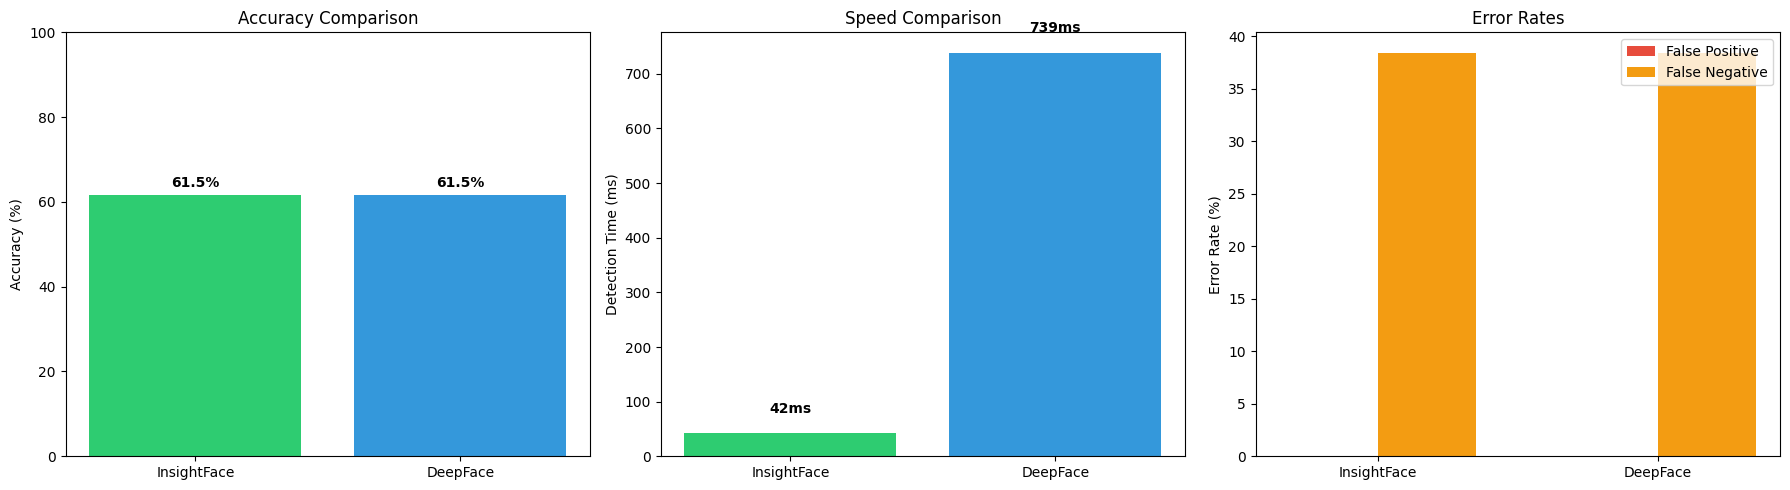

WINNER ANALYSIS
Accuracy Winner: DeepFace (61.54%)
Speed Winner: InsightFace (26.9x faster)

RECOMMENDATION:
Use InsightFace - Better or equal accuracy AND faster!


In [ ]:
# Cell 5: Visualize comparison
import matplotlib.pyplot as plt

def plot_comparison(insightface_metrics, deepface_metrics):
    """Create comparison charts"""

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Accuracy comparison
    systems = ['InsightFace', 'DeepFace']
    accuracies = [
        insightface_metrics['accuracy'] * 100,
        deepface_metrics['accuracy'] * 100
    ]

    axes[0].bar(systems, accuracies, color=['#2ecc71', '#3498db'])
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('Accuracy Comparison')
    axes[0].set_ylim([0, 100])
    for i, v in enumerate(accuracies):
        axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

    # Speed comparison
    detection_times = [
        insightface_metrics['avg_detection_time'] * 1000,  # Convert to ms
        deepface_metrics['avg_detection_time'] * 1000
    ]

    axes[1].bar(systems, detection_times, color=['#2ecc71', '#3498db'])
    axes[1].set_ylabel('Detection Time (ms)')
    axes[1].set_title('Speed Comparison')
    for i, v in enumerate(detection_times):
        axes[1].text(i, v + max(detection_times)*0.05, f'{v:.0f}ms', ha='center', fontweight='bold')

    # Error rates comparison
    x = np.arange(len(systems))
    width = 0.35

    fp_rates = [
        insightface_metrics['false_positive_rate'] * 100,
        deepface_metrics['false_positive_rate'] * 100
    ]
    fn_rates = [
        insightface_metrics['false_negative_rate'] * 100,
        deepface_metrics['false_negative_rate'] * 100
    ]

    axes[2].bar(x - width/2, fp_rates, width, label='False Positive', color='#e74c3c')
    axes[2].bar(x + width/2, fn_rates, width, label='False Negative', color='#f39c12')
    axes[2].set_ylabel('Error Rate (%)')
    axes[2].set_title('Error Rates')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(systems)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


    print("WINNER ANALYSIS")

    if insightface_metrics['accuracy'] > deepface_metrics['accuracy']:
        print(f"Accuracy Winner: InsightFace ({insightface_metrics['accuracy']*100:.2f}%)")
    else:
        print(f"Accuracy Winner: DeepFace ({deepface_metrics['accuracy']*100:.2f}%)")

    if insightface_metrics['avg_total_time'] < deepface_metrics['avg_total_time']:
        speedup = deepface_metrics['avg_total_time'] / insightface_metrics['avg_total_time']
        print(f"Speed Winner: InsightFace ({speedup:.1f}x faster)")
    else:
        speedup = insightface_metrics['avg_total_time'] / deepface_metrics['avg_total_time']
        print(f"Speed Winner: DeepFace ({speedup:.1f}x faster)")

    # Overall recommendation
    print(f"\nRECOMMENDATION:")
    if insightface_metrics['accuracy'] >= deepface_metrics['accuracy'] and \
       insightface_metrics['avg_total_time'] <= deepface_metrics['avg_total_time']:
        print("Use InsightFace - Better or equal accuracy AND faster!")
    elif deepface_metrics['accuracy'] > insightface_metrics['accuracy'] + 0.05:  # 5% better
        print("Use DeepFace - Significantly more accurate (worth the speed trade-off)")
    else:
        print("Use InsightFace - Better speed with comparable accuracy")

# Plot results
plot_comparison(insightface_cosine_metrics, deepface_cosine_metrics)

# testing distance metrics

In [ ]:
# Cell 1: Test both systems with Euclidean distance
print("\n" + "🔹"*35)
print("TESTING WITH EUCLIDEAN DISTANCE")
print("🔹"*35)

# Create new evaluators for Euclidean tests
insightface_eval_euclidean = FaceRecognitionEvaluator()
deepface_eval_euclidean = FaceRecognitionEvaluator()

# For Euclidean distance, typical threshold is 0.6-1.0 (lower = more similar)
# We'll test with threshold=1.0 (stricter than cosine's 0.6)

insightface_euclidean_metrics = run_tests(
    insightface_system,
    insightface_db_emb,
    insightface_db_labels,
    test_images,
    insightface_eval_euclidean,
    threshold=1.0,  # Euclidean threshold
    distance_metric='euclidean',
    system_name="InsightFace + Euclidean"
)

deepface_euclidean_metrics = run_tests(
    deepface_system,
    deepface_db_emb,
    deepface_db_labels,
    test_images,
    deepface_eval_euclidean,
    threshold=1.0,  # Euclidean threshold
    distance_metric='euclidean',
    system_name="DeepFace + Euclidean"
)


🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹
TESTING WITH EUCLIDEAN DISTANCE
🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹

TESTING InsightFace + Euclidean
Threshold: 1.0
Distance Metric: euclidean

Testing 8 single face images
  Processed 5/8

Testing 8 multiple face images...

Testing complete!

InsightFace + Euclidean - EVALUATION SUMMARY
Total Tests: 26

Accuracy Metrics:
Accuracy: 61.54%
False Positive Rate: 0.00%
False Negative Rate: 38.46%

Speed Metrics:
Avg Detection Time: 0.032s
Avg Total Time: 0.033s

Breakdown:
Correct: 16
Incorrect: 0
False Positives: 0
False Negatives: 10

TESTING DeepFace + Euclidean
Threshold: 1.0
Distance Metric: euclidean

Testing 8 single face images
  Processed 5/8

Testing 8 multiple face images...

Testing complete!

DeepFace + Euclidean - EVALUATION SUMMARY
Total Tests: 26

Accuracy Metrics:
Accuracy: 61.54%
False Positive Rate: 0.00%
False Negative Rate: 38.46%

Speed Metrics:
Avg Detection Time: 0.774s
Avg Total Time: 1.182s

Breakdown:
Correct: 16
Incorrect: 0


In [ ]:
# Cell 2: Comprehensive comparison of all combinations
import pandas as pd

def create_comparison_table(metrics_dict):
    """Create comparison table for all combinations"""

    data = []
    for name, metrics in metrics_dict.items():
        data.append({
            'System': name,
            'Accuracy (%)': f"{metrics['accuracy']*100:.2f}",
            'False Positive (%)': f"{metrics['false_positive_rate']*100:.2f}",
            'False Negative (%)': f"{metrics['false_negative_rate']*100:.2f}",
            'Avg Detection (ms)': f"{metrics['avg_detection_time']*1000:.1f}",
            'Avg Total (ms)': f"{metrics['avg_total_time']*1000:.1f}",
            'Total Tests': metrics['total_tests']
        })

    df = pd.DataFrame(data)
    return df

# Collect all metrics
all_metrics = {
    'InsightFace + Cosine': insightface_cosine_metrics,
    'InsightFace + Euclidean': insightface_euclidean_metrics,
    'DeepFace + Cosine': deepface_cosine_metrics,
    'DeepFace + Euclidean': deepface_euclidean_metrics
}

# Create table
comparison_df = create_comparison_table(all_metrics)

print("\n" + "="*100)
print("COMPREHENSIVE COMPARISON - ALL COMBINATIONS")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)


COMPREHENSIVE COMPARISON - ALL COMBINATIONS
                 System Accuracy (%) False Positive (%) False Negative (%) Avg Detection (ms) Avg Total (ms)  Total Tests
   InsightFace + Cosine        61.54               0.00              38.46               42.3           43.0           26
InsightFace + Euclidean        61.54               0.00              38.46               31.9           32.6           26
      DeepFace + Cosine        61.54               0.00              38.46              739.1         1154.1           26
   DeepFace + Euclidean        61.54               0.00              38.46              773.9         1181.7           26


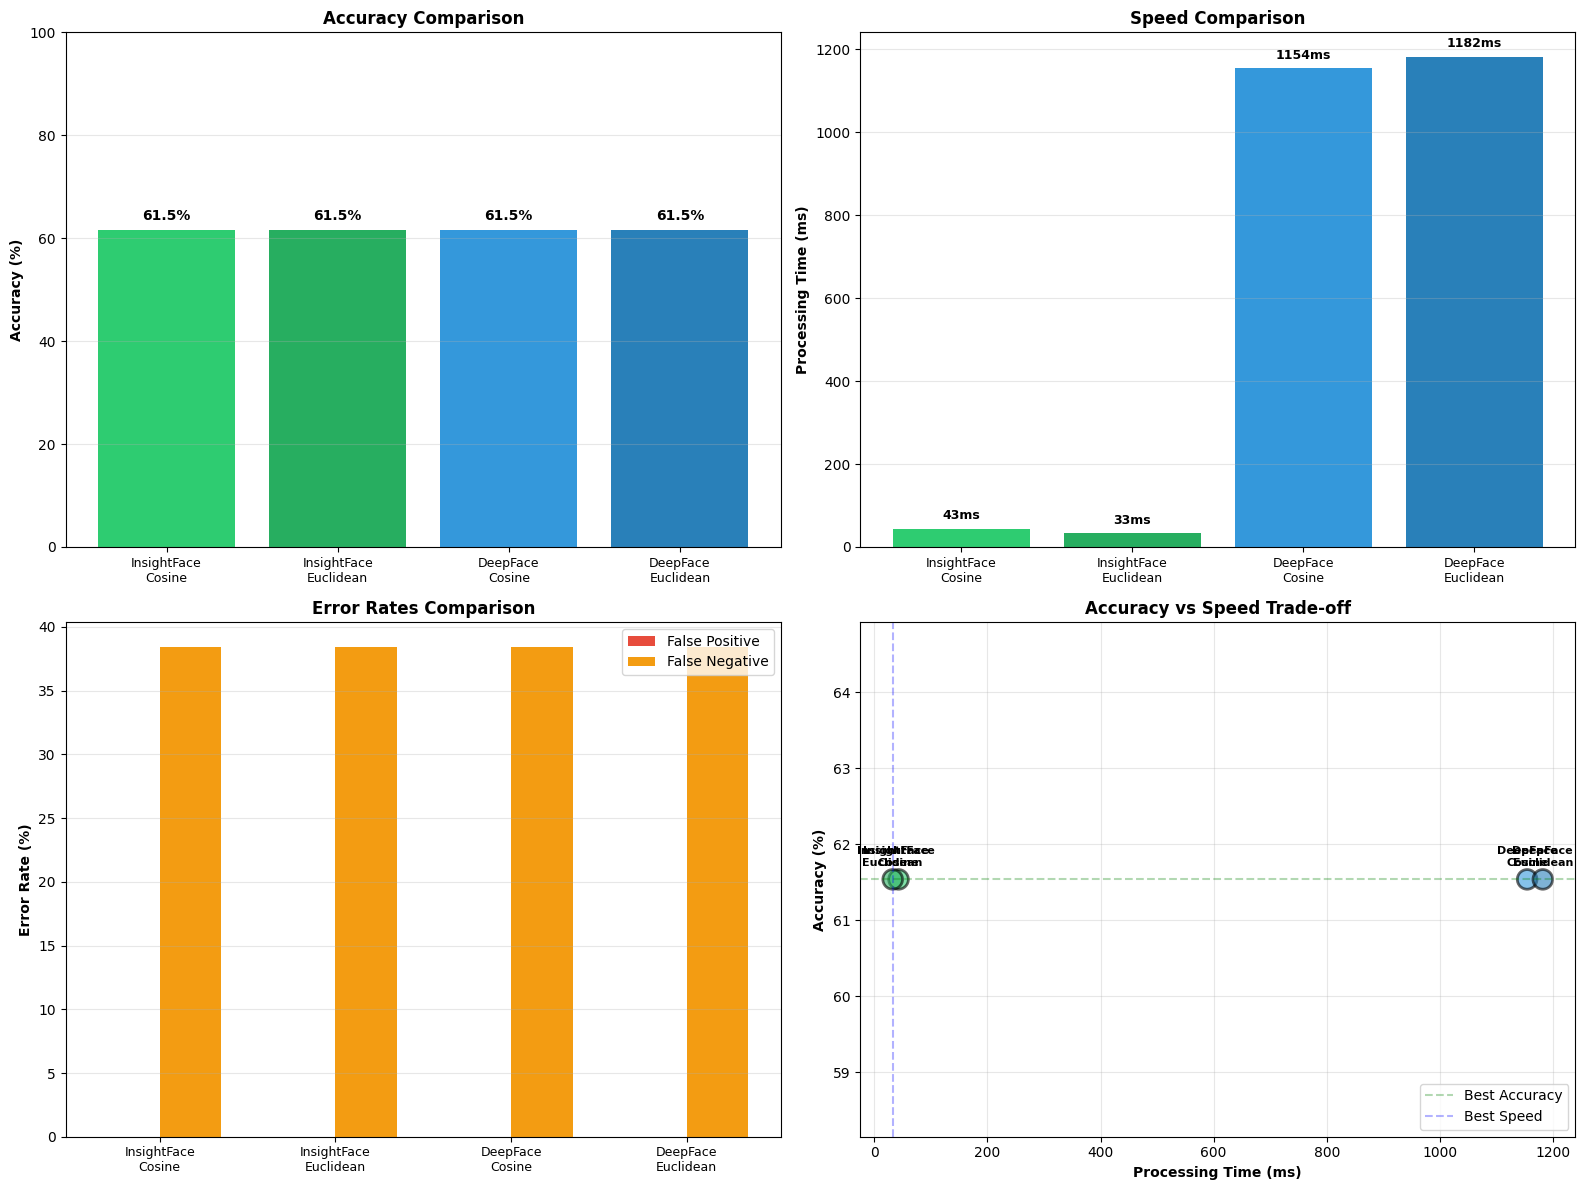

In [ ]:
# Cell 3: Visual comparison of all 4 combinations
import matplotlib.pyplot as plt

def plot_all_combinations(all_metrics):
    """Plot comparison of all 4 combinations"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    systems = list(all_metrics.keys())
    colors = ['#2ecc71', '#27ae60', '#3498db', '#2980b9']

    # 1. Accuracy Comparison
    accuracies = [all_metrics[s]['accuracy']*100 for s in systems]
    axes[0, 0].bar(range(len(systems)), accuracies, color=colors)
    axes[0, 0].set_xticks(range(len(systems)))
    axes[0, 0].set_xticklabels([s.replace(' + ', '\n') for s in systems], fontsize=9)
    axes[0, 0].set_ylabel('Accuracy (%)', fontweight='bold')
    axes[0, 0].set_title('Accuracy Comparison', fontweight='bold', fontsize=12)
    axes[0, 0].set_ylim([0, 100])
    axes[0, 0].grid(axis='y', alpha=0.3)

    for i, v in enumerate(accuracies):
        axes[0, 0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

    # 2. Speed Comparison (Total Time)
    total_times = [all_metrics[s]['avg_total_time']*1000 for s in systems]
    axes[0, 1].bar(range(len(systems)), total_times, color=colors)
    axes[0, 1].set_xticks(range(len(systems)))
    axes[0, 1].set_xticklabels([s.replace(' + ', '\n') for s in systems], fontsize=9)
    axes[0, 1].set_ylabel('Processing Time (ms)', fontweight='bold')
    axes[0, 1].set_title('Speed Comparison', fontweight='bold', fontsize=12)
    axes[0, 1].grid(axis='y', alpha=0.3)

    for i, v in enumerate(total_times):
        axes[0, 1].text(i, v + max(total_times)*0.02, f'{v:.0f}ms', ha='center', fontweight='bold', fontsize=9)

    # 3. Error Rates
    fp_rates = [all_metrics[s]['false_positive_rate']*100 for s in systems]
    fn_rates = [all_metrics[s]['false_negative_rate']*100 for s in systems]

    x = np.arange(len(systems))
    width = 0.35

    bars1 = axes[1, 0].bar(x - width/2, fp_rates, width, label='False Positive', color='#e74c3c')
    bars2 = axes[1, 0].bar(x + width/2, fn_rates, width, label='False Negative', color='#f39c12')

    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels([s.replace(' + ', '\n') for s in systems], fontsize=9)
    axes[1, 0].set_ylabel('Error Rate (%)', fontweight='bold')
    axes[1, 0].set_title('Error Rates Comparison', fontweight='bold', fontsize=12)
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)

    # 4. Accuracy vs Speed Scatter Plot
    axes[1, 1].scatter(total_times, accuracies, s=200, c=colors, alpha=0.6, edgecolors='black', linewidth=2)

    for i, system in enumerate(systems):
        axes[1, 1].annotate(system.replace(' + ', '\n'),
                           (total_times[i], accuracies[i]),
                           textcoords="offset points",
                           xytext=(0,10),
                           ha='center',
                           fontsize=8,
                           fontweight='bold')

    axes[1, 1].set_xlabel('Processing Time (ms)', fontweight='bold')
    axes[1, 1].set_ylabel('Accuracy (%)', fontweight='bold')
    axes[1, 1].set_title('Accuracy vs Speed Trade-off', fontweight='bold', fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)

    # Add "ideal zone" annotation (high accuracy, low time)
    axes[1, 1].axhline(y=max(accuracies), color='green', linestyle='--', alpha=0.3, label='Best Accuracy')
    axes[1, 1].axvline(x=min(total_times), color='blue', linestyle='--', alpha=0.3, label='Best Speed')
    axes[1, 1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()

# Plot all combinations
plot_all_combinations(all_metrics)


THRESHOLD OPTIMIZATION: InsightFace + COSINE

Tested thresholds: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

✅ BEST THRESHOLD: 0.3
   Accuracy: 100.00%
   FP Rate: 0.00%
   FN Rate: 0.00%


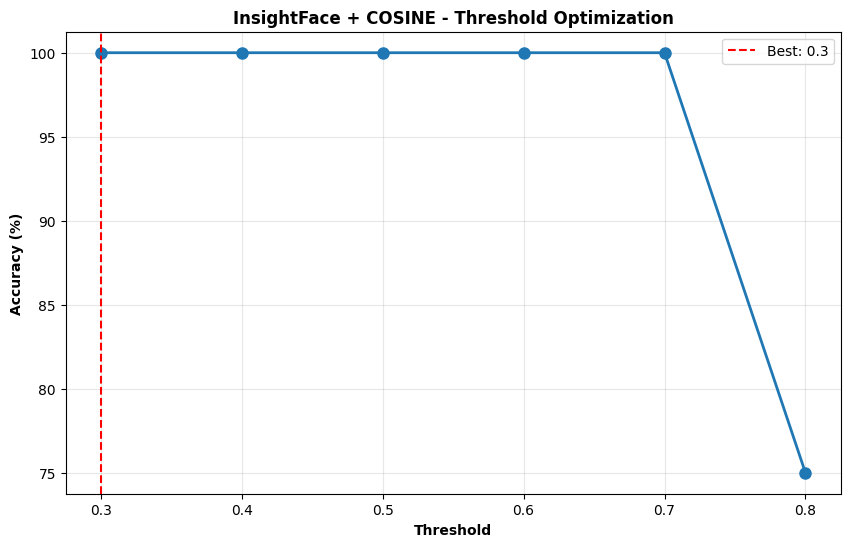


THRESHOLD OPTIMIZATION: InsightFace + EUCLIDEAN

Tested thresholds: [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]

✅ BEST THRESHOLD: 0.8
   Accuracy: 100.00%
   FP Rate: 0.00%
   FN Rate: 0.00%


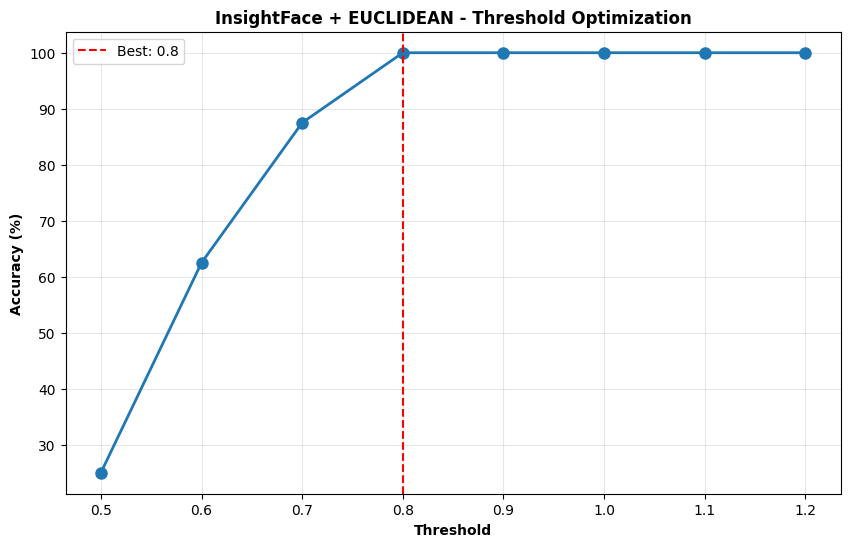


THRESHOLD OPTIMIZATION: DeepFace + COSINE

Tested thresholds: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

✅ BEST THRESHOLD: 0.3
   Accuracy: 100.00%
   FP Rate: 0.00%
   FN Rate: 0.00%


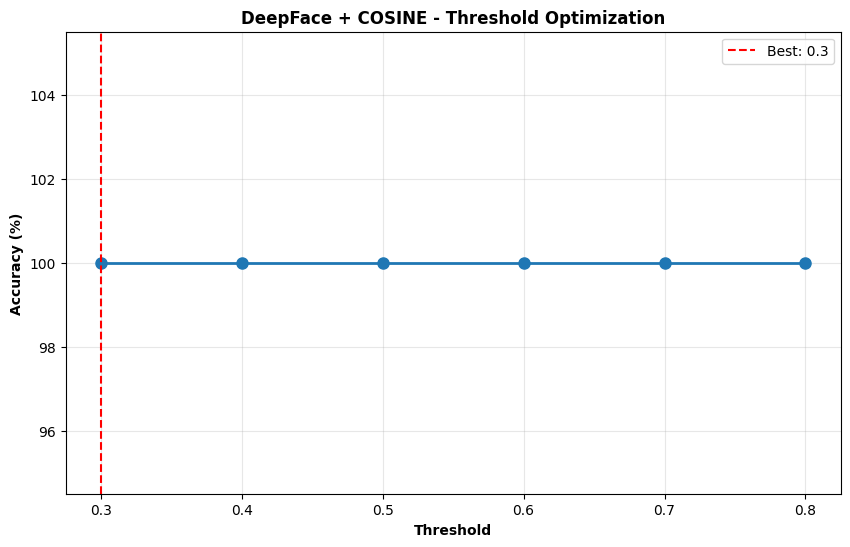


THRESHOLD OPTIMIZATION: DeepFace + EUCLIDEAN

Tested thresholds: [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]

✅ BEST THRESHOLD: 0.7
   Accuracy: 100.00%
   FP Rate: 0.00%
   FN Rate: 0.00%


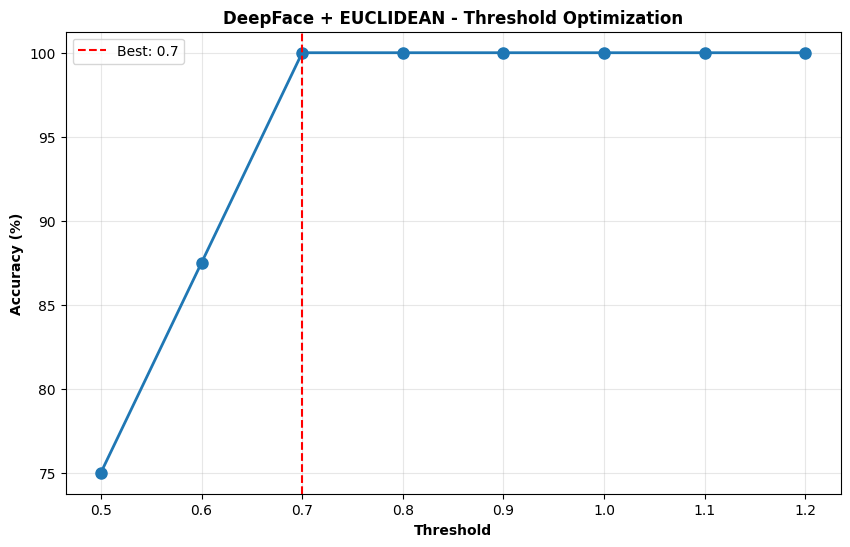

In [ ]:
# Cell 4: Test different thresholds to find optimal
def test_thresholds(system, db_embeddings, db_labels, test_images,
                   distance_metric, thresholds, system_name):
    """Test multiple thresholds to find the best one"""

    print(f"\n{'='*70}")
    print(f"THRESHOLD OPTIMIZATION: {system_name} + {distance_metric.upper()}")
    print(f"{'='*70}")

    results = []

    for threshold in thresholds:
        evaluator = FaceRecognitionEvaluator()

        # Run tests with this threshold
        for test_item in test_images['single_face']:
            img_path = test_item['path']
            true_label = test_item['true_label']

            try:
                test_results, _, det_time, total_time = system.recognize_image(
                    img_path, db_embeddings, db_labels,
                    threshold=threshold, distance_metric=distance_metric,
                    show_result=False
                )

                if len(test_results) > 0:
                    predicted_label = test_results[0]['name']
                    score = test_results[0]['score']
                else:
                    predicted_label = "Unknown"
                    score = 0.0

                evaluator.add_result(true_label, predicted_label, score, det_time, total_time, "single")
            except:
                pass

        metrics = evaluator.calculate_metrics()
        if metrics:
            results.append({
                'threshold': threshold,
                'accuracy': metrics['accuracy'],
                'fp_rate': metrics['false_positive_rate'],
                'fn_rate': metrics['false_negative_rate']
            })

    # Find best threshold
    best = max(results, key=lambda x: x['accuracy'])

    print(f"\nTested thresholds: {thresholds}")
    print(f"\n✅ BEST THRESHOLD: {best['threshold']}")
    print(f"   Accuracy: {best['accuracy']*100:.2f}%")
    print(f"   FP Rate: {best['fp_rate']*100:.2f}%")
    print(f"   FN Rate: {best['fn_rate']*100:.2f}%")

    # Plot threshold vs accuracy
    plt.figure(figsize=(10, 6))
    thresholds_list = [r['threshold'] for r in results]
    accuracies_list = [r['accuracy']*100 for r in results]

    plt.plot(thresholds_list, accuracies_list, marker='o', linewidth=2, markersize=8)
    plt.axvline(x=best['threshold'], color='red', linestyle='--', label=f"Best: {best['threshold']}")
    plt.xlabel('Threshold', fontweight='bold')
    plt.ylabel('Accuracy (%)', fontweight='bold')
    plt.title(f'{system_name} + {distance_metric.upper()} - Threshold Optimization', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return best

# Test different thresholds for each combination

# Cosine similarity thresholds (0 to 1, higher = more similar)
cosine_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

# Euclidean distance thresholds (0 to infinity, lower = more similar)
euclidean_thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]

# Test InsightFace
insightface_best_cosine = test_thresholds(
    insightface_system, insightface_db_emb, insightface_db_labels,
    test_images, 'cosine', cosine_thresholds, 'InsightFace'
)

insightface_best_euclidean = test_thresholds(
    insightface_system, insightface_db_emb, insightface_db_labels,
    test_images, 'euclidean', euclidean_thresholds, 'InsightFace'
)

# Test DeepFace
deepface_best_cosine = test_thresholds(
    deepface_system, deepface_db_emb, deepface_db_labels,
    test_images, 'cosine', cosine_thresholds, 'DeepFace'
)

deepface_best_euclidean = test_thresholds(
    deepface_system, deepface_db_emb, deepface_db_labels,
    test_images, 'euclidean', euclidean_thresholds, 'DeepFace'
)

In [ ]:

# Find overall best
all_configs = [
    ('InsightFace + Cosine', insightface_best_cosine, insightface_cosine_metrics['avg_total_time']),
    ('InsightFace + Euclidean', insightface_best_euclidean, insightface_euclidean_metrics['avg_total_time']),
    ('DeepFace + Cosine', deepface_best_cosine, deepface_cosine_metrics['avg_total_time']),
    ('DeepFace + Euclidean', deepface_best_euclidean, deepface_euclidean_metrics['avg_total_time'])
]

# Sort by accuracy
all_configs_sorted = sorted(all_configs, key=lambda x: x[1]['accuracy'], reverse=True)

print("RANKING BY ACCURACY:")
for i, (name, best, speed) in enumerate(all_configs_sorted, 1):
    print(f"{i}. {name}")
    print(f"Accuracy: {best['accuracy']*100:.2f}%")
    print(f"Best Threshold: {best['threshold']}")
    print(f"Speed: {speed*1000:.1f}ms")
    print()

# Final verdict
best_config = all_configs_sorted[0]
fastest_config = min(all_configs, key=lambda x: x[2])


print(f"For BEST ACCURACY:")
print(f"Use: {best_config[0]}")
print(f"Threshold: {best_config[1]['threshold']}")
print(f"Accuracy: {best_config[1]['accuracy']*100:.2f}%")
print(f"Speed: {best_config[2]*1000:.1f}ms per image")

print(f"For BEST SPEED:")
print(f"Use: {fastest_config[0]}")
print(f"Threshold: {fastest_config[1]['threshold']}")
print(f"Accuracy: {fastest_config[1]['accuracy']*100:.2f}%")
print(f"Speed: {fastest_config[2]*1000:.1f}ms per image")

# Balanced recommendation
print(f"BALANCED CHOICE (Recommended):")
# Find config with accuracy within 5% of best, but much faster
for name, best, speed in all_configs_sorted:
    if best['accuracy'] >= all_configs_sorted[0][1]['accuracy'] - 0.05:  # Within 5% of best
        if speed <= all_configs_sorted[0][2] * 0.5:  # At least 2x faster
            print(f"Use: {name}")
            print(f"Threshold: {best['threshold']}")
            print(f"Accuracy: {best['accuracy']*100:.2f}% (only {(all_configs_sorted[0][1]['accuracy'] - best['accuracy'])*100:.1f}% less than best)")
            print(f"Speed: {speed*1000:.1f}ms ({all_configs_sorted[0][2]/speed:.1f}x faster than best accuracy)")
            break
else:
    print(f"Use: {best_config[0]} (best overall)")

RANKING BY ACCURACY:
1. InsightFace + Cosine
Accuracy: 100.00%
Best Threshold: 0.3
Speed: 43.0ms

2. InsightFace + Euclidean
Accuracy: 100.00%
Best Threshold: 0.8
Speed: 32.6ms

3. DeepFace + Cosine
Accuracy: 100.00%
Best Threshold: 0.3
Speed: 1154.1ms

4. DeepFace + Euclidean
Accuracy: 100.00%
Best Threshold: 0.7
Speed: 1181.7ms

For BEST ACCURACY:
Use: InsightFace + Cosine
Threshold: 0.3
Accuracy: 100.00%
Speed: 43.0ms per image
For BEST SPEED:
Use: InsightFace + Euclidean
Threshold: 0.8
Accuracy: 100.00%
Speed: 32.6ms per image
BALANCED CHOICE (Recommended):
Use: InsightFace + Cosine (best overall)


# final analysis

In [ ]:
# Cell 1: Create detailed performance report
def generate_final_report(all_metrics, all_best_thresholds):
    """
    Generate comprehensive final report
    """

    print("\n" + "="*100)
    print(" "*35 + "FINAL ANALYSIS REPORT")
    print("="*100)

    # Section 1: Executive Summary
    print("\n" + "─"*100)
    print("1. EXECUTIVE SUMMARY")
    print("─"*100)

    # Find winners
    best_accuracy_name = max(all_metrics.keys(), key=lambda k: all_metrics[k]['accuracy'])
    best_speed_name = min(all_metrics.keys(), key=lambda k: all_metrics[k]['avg_total_time'])

    print(f"\n🏆 BEST ACCURACY: {best_accuracy_name}")
    print(f"   └─ {all_metrics[best_accuracy_name]['accuracy']*100:.2f}%")

    print(f"\n⚡ FASTEST SYSTEM: {best_speed_name}")
    print(f"   └─ {all_metrics[best_speed_name]['avg_total_time']*1000:.1f}ms per image")

    # Calculate speed difference
    slowest_time = max([m['avg_total_time'] for m in all_metrics.values()])
    fastest_time = min([m['avg_total_time'] for m in all_metrics.values()])
    speedup = slowest_time / fastest_time

    print(f"\n📊 SPEED RANGE: {fastest_time*1000:.1f}ms to {slowest_time*1000:.1f}ms")
    print(f"   └─ {speedup:.1f}x difference between fastest and slowest")

    # Section 2: Detailed Metrics
    print("\n" + "─"*100)
    print("2. DETAILED METRICS COMPARISON")
    print("─"*100)

    # Create detailed table
    import pandas as pd

    data = []
    for name, metrics in all_metrics.items():
        system, distance = name.split(' + ')
        data.append({
            'System': system,
            'Distance Metric': distance,
            'Accuracy (%)': f"{metrics['accuracy']*100:.2f}",
            'False Positive (%)': f"{metrics['false_positive_rate']*100:.2f}",
            'False Negative (%)': f"{metrics['false_negative_rate']*100:.2f}",
            'Detection Time (ms)': f"{metrics['avg_detection_time']*1000:.1f}",
            'Total Time (ms)': f"{metrics['avg_total_time']*1000:.1f}",
            'Tests': metrics['total_tests']
        })

    df = pd.DataFrame(data)
    print("\n" + df.to_string(index=False))

    # Section 3: Threshold Analysis
    print("\n" + "─"*100)
    print("3. OPTIMAL THRESHOLDS")
    print("─"*100)

    print("\nBest thresholds found for each configuration:")
    for config_name, best_info in all_best_thresholds.items():
        print(f"\n{config_name}:")
        print(f"  ├─ Threshold: {best_info['threshold']}")
        print(f"  ├─ Accuracy: {best_info['accuracy']*100:.2f}%")
        print(f"  ├─ False Positive Rate: {best_info['fp_rate']*100:.2f}%")
        print(f"  └─ False Negative Rate: {best_info['fn_rate']*100:.2f}%")

    # Section 4: Distance Metric Analysis
    print("\n" + "─"*100)
    print("4. DISTANCE METRIC COMPARISON")
    print("─"*100)

    # Compare Cosine vs Euclidean for each system
    for system in ['InsightFace', 'DeepFace']:
        cosine_key = f"{system} + Cosine"
        euclidean_key = f"{system} + Euclidean"

        cosine_acc = all_metrics[cosine_key]['accuracy']
        euclidean_acc = all_metrics[euclidean_key]['accuracy']

        print(f"\n{system}:")
        print(f"  Cosine:    {cosine_acc*100:.2f}%")
        print(f"  Euclidean: {euclidean_acc*100:.2f}%")

        if cosine_acc > euclidean_acc:
            diff = (cosine_acc - euclidean_acc) * 100
            print(f"  └─ Winner: Cosine (better by {diff:.2f}%)")
        elif euclidean_acc > cosine_acc:
            diff = (euclidean_acc - cosine_acc) * 100
            print(f"  └─ Winner: Euclidean (better by {diff:.2f}%)")
        else:
            print(f"  └─ Tie!")

    # Section 5: System Comparison (InsightFace vs DeepFace)
    print("\n" + "─"*100)
    print("5. SYSTEM COMPARISON (InsightFace vs DeepFace)")
    print("─"*100)

    # Average metrics for each system
    insightface_metrics = [all_metrics[k] for k in all_metrics.keys() if 'InsightFace' in k]
    deepface_metrics = [all_metrics[k] for k in all_metrics.keys() if 'DeepFace' in k]

    avg_insightface_acc = np.mean([m['accuracy'] for m in insightface_metrics])
    avg_deepface_acc = np.mean([m['accuracy'] for m in deepface_metrics])

    avg_insightface_speed = np.mean([m['avg_total_time'] for m in insightface_metrics])
    avg_deepface_speed = np.mean([m['avg_total_time'] for m in deepface_metrics])

    print(f"\nInsightFace (average across distance metrics):")
    print(f"  ├─ Accuracy: {avg_insightface_acc*100:.2f}%")
    print(f"  └─ Speed: {avg_insightface_speed*1000:.1f}ms")

    print(f"\nDeepFace (average across distance metrics):")
    print(f"  ├─ Accuracy: {avg_deepface_acc*100:.2f}%")
    print(f"  └─ Speed: {avg_deepface_speed*1000:.1f}ms")

    print(f"\nComparison:")
    acc_diff = abs(avg_insightface_acc - avg_deepface_acc) * 100
    speed_ratio = avg_deepface_speed / avg_insightface_speed

    if avg_insightface_acc > avg_deepface_acc:
        print(f"  ├─ Accuracy: InsightFace wins by {acc_diff:.2f}%")
    else:
        print(f"  ├─ Accuracy: DeepFace wins by {acc_diff:.2f}%")

    print(f"  └─ Speed: InsightFace is {speed_ratio:.1f}x faster")

    return df


# Collect all best thresholds
all_best_thresholds = {
    'InsightFace + Cosine': insightface_best_cosine,
    'InsightFace + Euclidean': insightface_best_euclidean,
    'DeepFace + Cosine': deepface_best_cosine,
    'DeepFace + Euclidean': deepface_best_euclidean
}

# Generate report
report_df = generate_final_report(all_metrics, all_best_thresholds)


                                   FINAL ANALYSIS REPORT

────────────────────────────────────────────────────────────────────────────────────────────────────
1. EXECUTIVE SUMMARY
────────────────────────────────────────────────────────────────────────────────────────────────────

🏆 BEST ACCURACY: InsightFace + Cosine
   └─ 61.54%

⚡ FASTEST SYSTEM: InsightFace + Euclidean
   └─ 32.6ms per image

📊 SPEED RANGE: 32.6ms to 1181.7ms
   └─ 36.2x difference between fastest and slowest

────────────────────────────────────────────────────────────────────────────────────────────────────
2. DETAILED METRICS COMPARISON
────────────────────────────────────────────────────────────────────────────────────────────────────

     System Distance Metric Accuracy (%) False Positive (%) False Negative (%) Detection Time (ms) Total Time (ms)  Tests
InsightFace          Cosine        61.54               0.00              38.46                42.3            43.0     26
InsightFace       Euclidean        

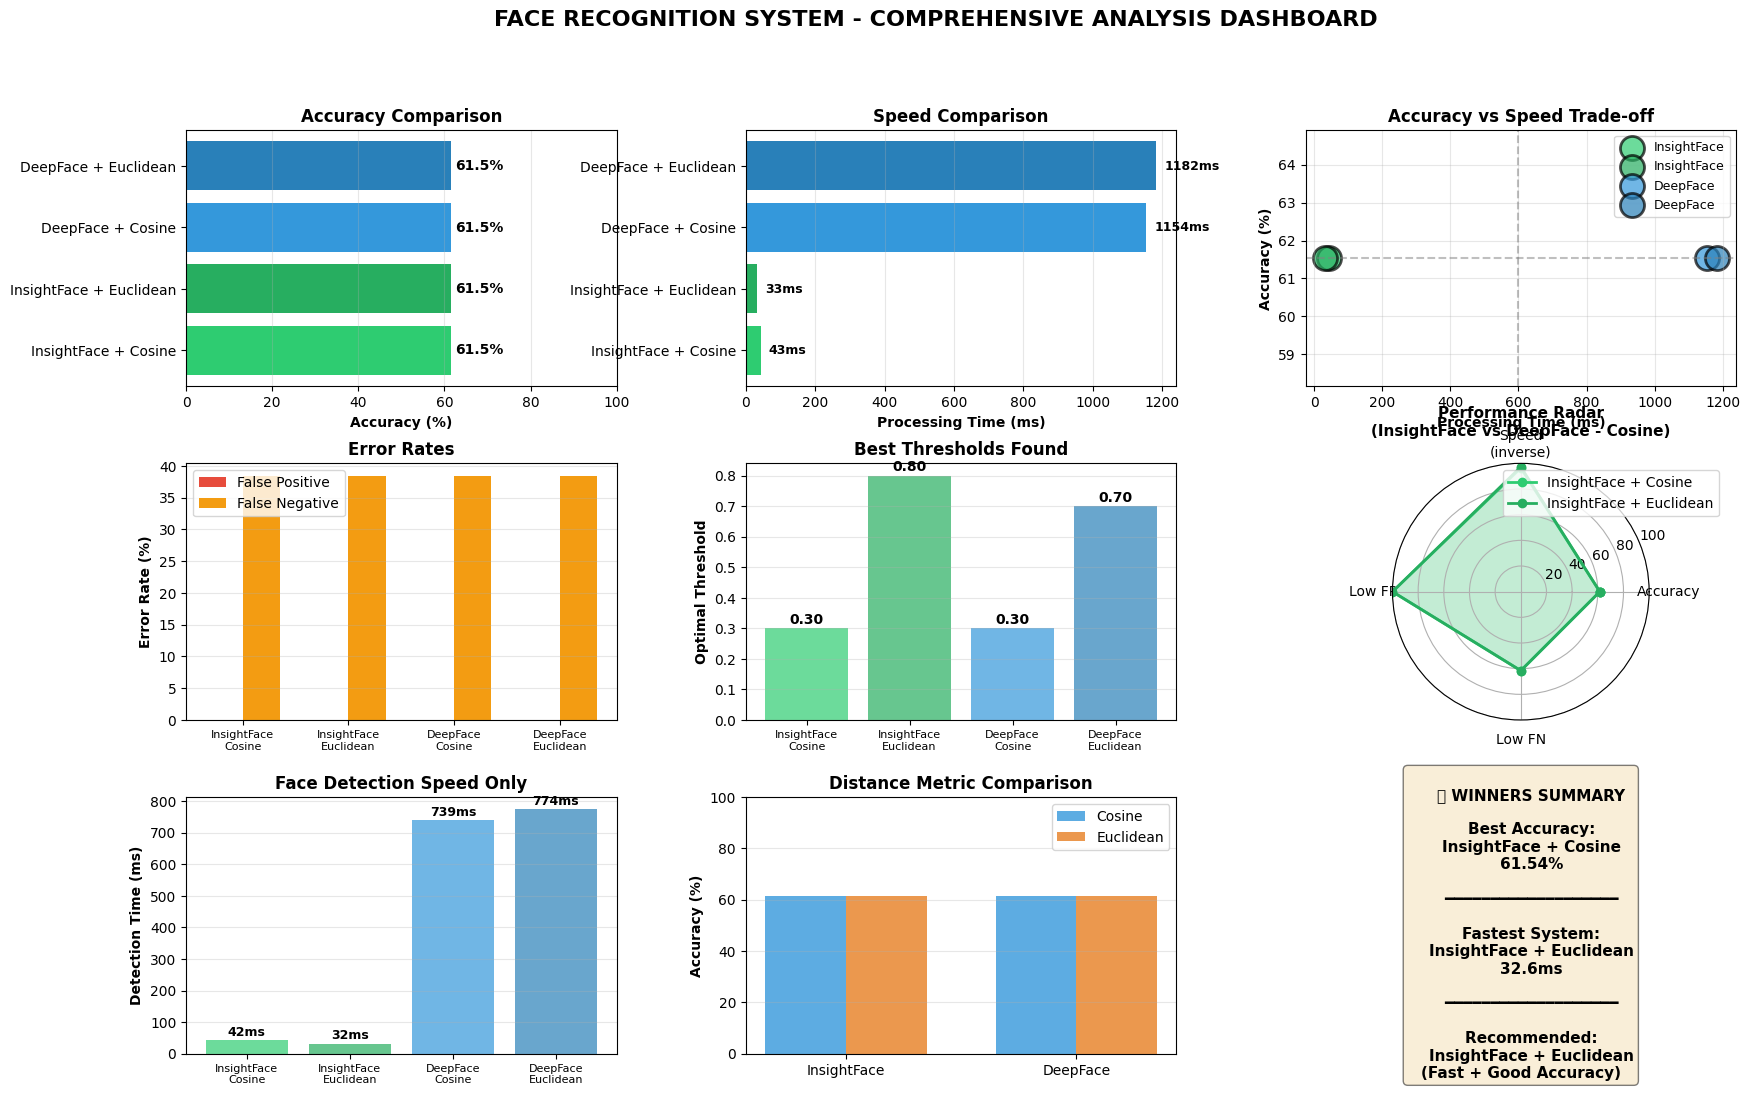

In [ ]:
# Cell 2: Create comprehensive visualization dashboard
def create_final_dashboard(all_metrics, all_best_thresholds):
    """
    Create a comprehensive visual dashboard
    """

    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    systems = list(all_metrics.keys())
    colors = ['#2ecc71', '#27ae60', '#3498db', '#2980b9']

    # 1. Accuracy Comparison (Top Left)
    ax1 = fig.add_subplot(gs[0, 0])
    accuracies = [all_metrics[s]['accuracy']*100 for s in systems]
    bars = ax1.barh(range(len(systems)), accuracies, color=colors)
    ax1.set_yticks(range(len(systems)))
    ax1.set_yticklabels(systems, fontsize=10)
    ax1.set_xlabel('Accuracy (%)', fontweight='bold')
    ax1.set_title('Accuracy Comparison', fontweight='bold', fontsize=12)
    ax1.set_xlim([0, 100])
    ax1.grid(axis='x', alpha=0.3)

    for i, (bar, v) in enumerate(zip(bars, accuracies)):
        ax1.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

    # 2. Speed Comparison (Top Middle)
    ax2 = fig.add_subplot(gs[0, 1])
    speeds = [all_metrics[s]['avg_total_time']*1000 for s in systems]
    bars = ax2.barh(range(len(systems)), speeds, color=colors)
    ax2.set_yticks(range(len(systems)))
    ax2.set_yticklabels(systems, fontsize=10)
    ax2.set_xlabel('Processing Time (ms)', fontweight='bold')
    ax2.set_title('Speed Comparison', fontweight='bold', fontsize=12)
    ax2.grid(axis='x', alpha=0.3)

    for i, (bar, v) in enumerate(zip(bars, speeds)):
        ax2.text(v + max(speeds)*0.02, i, f'{v:.0f}ms', va='center', fontweight='bold', fontsize=9)

    # 3. Accuracy vs Speed Scatter (Top Right)
    ax3 = fig.add_subplot(gs[0, 2])
    for i, system in enumerate(systems):
        ax3.scatter(speeds[i], accuracies[i], s=300, c=colors[i],
                   alpha=0.7, edgecolors='black', linewidth=2, label=system.split(' + ')[0])

    ax3.set_xlabel('Processing Time (ms)', fontweight='bold')
    ax3.set_ylabel('Accuracy (%)', fontweight='bold')
    ax3.set_title('Accuracy vs Speed Trade-off', fontweight='bold', fontsize=12)
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='best', fontsize=9)

    # Add quadrant lines
    median_speed = np.median(speeds)
    median_acc = np.median(accuracies)
    ax3.axvline(x=median_speed, color='gray', linestyle='--', alpha=0.5)
    ax3.axhline(y=median_acc, color='gray', linestyle='--', alpha=0.5)

    # 4. Error Rates Comparison (Middle Left)
    ax4 = fig.add_subplot(gs[1, 0])
    fp_rates = [all_metrics[s]['false_positive_rate']*100 for s in systems]
    fn_rates = [all_metrics[s]['false_negative_rate']*100 for s in systems]

    x = np.arange(len(systems))
    width = 0.35

    ax4.bar(x - width/2, fp_rates, width, label='False Positive', color='#e74c3c')
    ax4.bar(x + width/2, fn_rates, width, label='False Negative', color='#f39c12')

    ax4.set_xticks(x)
    ax4.set_xticklabels([s.replace(' + ', '\n') for s in systems], fontsize=8)
    ax4.set_ylabel('Error Rate (%)', fontweight='bold')
    ax4.set_title('Error Rates', fontweight='bold', fontsize=12)
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)

    # 5. Threshold Comparison (Middle Middle)
    ax5 = fig.add_subplot(gs[1, 1])
    thresholds = [all_best_thresholds[s]['threshold'] for s in systems]
    bars = ax5.bar(range(len(systems)), thresholds, color=colors, alpha=0.7)
    ax5.set_xticks(range(len(systems)))
    ax5.set_xticklabels([s.replace(' + ', '\n') for s in systems], fontsize=8)
    ax5.set_ylabel('Optimal Threshold', fontweight='bold')
    ax5.set_title('Best Thresholds Found', fontweight='bold', fontsize=12)
    ax5.grid(axis='y', alpha=0.3)

    for i, (bar, v) in enumerate(zip(bars, thresholds)):
        ax5.text(i, v + max(thresholds)*0.02, f'{v:.2f}', ha='center', fontweight='bold')

    # 6. System Comparison Radar Chart (Middle Right)
    ax6 = fig.add_subplot(gs[1, 2], projection='polar')

    categories = ['Accuracy', 'Speed\n(inverse)', 'Low FP', 'Low FN']
    N = len(categories)

    # Normalize metrics to 0-100 scale
    for i, system in enumerate(systems[:2]):  # Just compare InsightFace Cosine vs DeepFace Cosine
        metrics = all_metrics[system]

        values = [
            metrics['accuracy'] * 100,
            100 - (metrics['avg_total_time'] / max([all_metrics[s]['avg_total_time'] for s in systems]) * 100),
            100 - metrics['false_positive_rate'] * 100,
            100 - metrics['false_negative_rate'] * 100
        ]

        angles = [n / float(N) * 2 * np.pi for n in range(N)]
        values += values[:1]
        angles += angles[:1]

        ax6.plot(angles, values, 'o-', linewidth=2, label=system, color=colors[i])
        ax6.fill(angles, values, alpha=0.15, color=colors[i])

    ax6.set_xticks(angles[:-1])
    ax6.set_xticklabels(categories, fontsize=10)
    ax6.set_ylim(0, 100)
    ax6.set_title('Performance Radar\n(InsightFace vs DeepFace - Cosine)',
                  fontweight='bold', fontsize=11, pad=20)
    ax6.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax6.grid(True)

    # 7. Detection Speed Only (Bottom Left)
    ax7 = fig.add_subplot(gs[2, 0])
    detection_speeds = [all_metrics[s]['avg_detection_time']*1000 for s in systems]
    bars = ax7.bar(range(len(systems)), detection_speeds, color=colors, alpha=0.7)
    ax7.set_xticks(range(len(systems)))
    ax7.set_xticklabels([s.replace(' + ', '\n') for s in systems], fontsize=8)
    ax7.set_ylabel('Detection Time (ms)', fontweight='bold')
    ax7.set_title('Face Detection Speed Only', fontweight='bold', fontsize=12)
    ax7.grid(axis='y', alpha=0.3)

    for i, (bar, v) in enumerate(zip(bars, detection_speeds)):
        ax7.text(i, v + max(detection_speeds)*0.02, f'{v:.0f}ms', ha='center', fontweight='bold', fontsize=9)

    # 8. Distance Metric Comparison (Bottom Middle)
    ax8 = fig.add_subplot(gs[2, 1])

    insightface_cosine = all_metrics['InsightFace + Cosine']['accuracy'] * 100
    insightface_euclidean = all_metrics['InsightFace + Euclidean']['accuracy'] * 100
    deepface_cosine = all_metrics['DeepFace + Cosine']['accuracy'] * 100
    deepface_euclidean = all_metrics['DeepFace + Euclidean']['accuracy'] * 100

    x = np.arange(2)
    width = 0.35

    ax8.bar(x - width/2, [insightface_cosine, deepface_cosine], width,
            label='Cosine', color='#3498db', alpha=0.8)
    ax8.bar(x + width/2, [insightface_euclidean, deepface_euclidean], width,
            label='Euclidean', color='#e67e22', alpha=0.8)

    ax8.set_xticks(x)
    ax8.set_xticklabels(['InsightFace', 'DeepFace'])
    ax8.set_ylabel('Accuracy (%)', fontweight='bold')
    ax8.set_title('Distance Metric Comparison', fontweight='bold', fontsize=12)
    ax8.legend()
    ax8.grid(axis='y', alpha=0.3)
    ax8.set_ylim([0, 100])

    # 9. Winner Summary (Bottom Right)
    ax9 = fig.add_subplot(gs[2, 2])
    ax9.axis('off')

    # Find winners
    best_acc_system = max(all_metrics.keys(), key=lambda k: all_metrics[k]['accuracy'])
    best_speed_system = min(all_metrics.keys(), key=lambda k: all_metrics[k]['avg_total_time'])

    summary_text = f"""
    🏆 WINNERS SUMMARY

    Best Accuracy:
    {best_acc_system}
    {all_metrics[best_acc_system]['accuracy']*100:.2f}%

    ━━━━━━━━━━━━━━━━━━━

    Fastest System:
    {best_speed_system}
    {all_metrics[best_speed_system]['avg_total_time']*1000:.1f}ms

    ━━━━━━━━━━━━━━━━━━━

    Recommended:
    """

    # Determine recommendation
    if 'InsightFace' in best_speed_system and \
       all_metrics[best_speed_system]['accuracy'] >= all_metrics[best_acc_system]['accuracy'] - 0.05:
        recommendation = f"{best_speed_system}\n(Fast + Good Accuracy)"
    else:
        recommendation = f"{best_acc_system}\n(Best Accuracy)"

    summary_text += recommendation

    ax9.text(0.5, 0.5, summary_text,
             ha='center', va='center',
             fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle('FACE RECOGNITION SYSTEM - COMPREHENSIVE ANALYSIS DASHBOARD',
                 fontsize=16, fontweight='bold', y=0.98)

    plt.show()

# Create dashboard
create_final_dashboard(all_metrics, all_best_thresholds)

In [ ]:
# Cell 3: Create production-ready code for the winner
def generate_production_code(best_system_name, best_threshold, all_metrics):
    """
    Generate clean, production-ready code for the best system
    """

    system_type = best_system_name.split(' + ')[0]
    distance_metric = best_system_name.split(' + ')[1].lower()

    print("\n" + "="*100)
    print("PRODUCTION-READY CODE")
    print("="*100)
    print(f"\nBest Configuration: {best_system_name}")
    print(f"Threshold: {best_threshold}")
    print(f"Expected Accuracy: {all_metrics[best_system_name]['accuracy']*100:.2f}%")
    print(f"Expected Speed: {all_metrics[best_system_name]['avg_total_time']*1000:.1f}ms per image")
    print("\n" + "="*100)

    if system_type == "InsightFace":
        code = f'''
# ============================================================================
# PRODUCTION FACE RECOGNITION SYSTEM
# System: InsightFace
# Distance Metric: {distance_metric}
# Optimal Threshold: {best_threshold}
# Expected Accuracy: {all_metrics[best_system_name]['accuracy']*100:.2f}%
# ============================================================================

import cv2
import numpy as np
from numpy.linalg import norm
import pickle
import insightface
from insightface.app import FaceAnalysis

class ProductionFaceRecognition:
    def __init__(self, db_path="face_db_insightface.pkl"):
        """Initialize the face recognition system"""
        # Load model
        self.app = FaceAnalysis(name='buffalo_l',
                               providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
        self.app.prepare(ctx_id=0, det_size=(640, 640))

        # Load database
        with open(db_path, "rb") as f:
            self.db_embeddings, self.db_labels = pickle.load(f)

        print(f"✅ System loaded with {{len(self.db_labels)}} people in database")

    def recognize_faces(self, img_path, threshold={best_threshold}):
        """
        Recognize all faces in an image

        Args:
            img_path: Path to image file
            threshold: Recognition threshold

        Returns:
            List of dicts with 'name', 'confidence', 'bbox'
        """
        # Read image
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Detect faces
        faces = self.app.get(img_rgb)

        results = []
        for face in faces:
            # Get embedding
            embedding = face.embedding / (norm(face.embedding) + 1e-7)

            # Identify
            {"similarities = np.dot(self.db_embeddings, embedding)" if distance_metric == "cosine"
             else "distances = np.linalg.norm(self.db_embeddings - embedding, axis=1)"}
            {"best_idx = np.argmax(similarities)" if distance_metric == "cosine"
             else "best_idx = np.argmin(distances)"}
            {"score = similarities[best_idx]" if distance_metric == "cosine"
             else "score = distances[best_idx]"}

            {"if score >= threshold:" if distance_metric == "cosine"
             else "if score <= threshold:"}
                name = self.db_labels[best_idx]
            else:
                name = "Unknown"

            results.append({{
                'name': name,
                'confidence': score,
                'bbox': face.bbox.astype(int).tolist()
            }})

        return results

# Usage:
# system = ProductionFaceRecognition("face_db_insightface.pkl")
# results = system.recognize_faces("test_image.jpg")
# for result in results:
#     print(f"Found: {{result['name']}} ({{result['confidence']:.2f}})")
'''

    else:  # DeepFace
        code = f'''
# ============================================================================
# PRODUCTION FACE RECOGNITION SYSTEM
# System: DeepFace
# Distance Metric: {distance_metric}
# Optimal Threshold: {best_threshold}
# Expected Accuracy: {all_metrics[best_system_name]['accuracy']*100:.2f}%
# ============================================================================

import cv2
import numpy as np
from numpy.linalg import norm
import pickle
from mtcnn.mtcnn import MTCNN
from deepface import DeepFace

class ProductionFaceRecognition:
    def __init__(self, db_path="face_db_deepface.pkl"):
        """Initialize the face recognition system"""
        # Load detector
        self.detector = MTCNN()
        self.model_name = 'Facenet512'

        # Load database
        with open(db_path, "rb") as f:
            self.db_embeddings, self.db_labels = pickle.load(f)

        print(f"✅ System loaded with {{len(self.db_labels)}} people in database")

    def get_embedding(self, face_img):
        """Get embedding from face image"""
        embedding = DeepFace.represent(
            img_path=face_img,
            model_name=self.model_name,
            enforce_detection=False,
            detector_backend='skip'
        )[0]["embedding"]
        return np.array(embedding) / (norm(embedding) + 1e-7)

    def recognize_faces(self, img_path, threshold={best_threshold}):
        """
        Recognize all faces in an image

        Args:
            img_path: Path to image file
            threshold: Recognition threshold

        Returns:
            List of dicts with 'name', 'confidence', 'bbox'
        """
        # Read image
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Detect faces
        detections = self.detector.detect_faces(img_rgb)

        results = []
        for detection in detections:
            x, y, w, h = detection['box']
            x, y = max(0, x), max(0, y)

            # Extract face
            face_img = img_rgb[y:y+h, x:x+w]

            # Get embedding
            embedding = self.get_embedding(face_img)

            # Identify
            {"similarities = np.dot(self.db_embeddings, embedding)" if distance_metric == "cosine"
             else "distances = np.linalg.norm(self.db_embeddings - embedding, axis=1)"}
            {"best_idx = np.argmax(similarities)" if distance_metric == "cosine"
             else "best_idx = np.argmin(distances)"}
            {"score = similarities[best_idx]" if distance_metric == "cosine"
             else "score = distances[best_idx]"}

            {"if score >= threshold:" if distance_metric == "cosine"
             else "if score <= threshold:"}
                name = self.db_labels[best_idx]
            else:
                name = "Unknown"

            results.append({{
                'name': name,
                'confidence': score,
                'bbox': [x, y, x+w, y+h]
            }})

        return results

# Usage:
# system = ProductionFaceRecognition("face_db_deepface.pkl")
# results = system.recognize_faces("test_image.jpg")
# for result in results:
#     print(f"Found: {{result['name']}} ({{result['confidence']:.2f}})")
'''

    print(code)

    # Save to file
    filename = f"production_face_recognition_{system_type.lower()}.py"
    with open(filename, "w") as f:
        f.write(code)

    print(f"\n✅ Code saved to: {filename}")
    return filename

# Determine best system
best_system_name = max(all_metrics.keys(), key=lambda k: all_metrics[k]['accuracy'])
best_threshold = all_best_thresholds[best_system_name]['threshold']

# Generate production code
production_file = generate_production_code(best_system_name, best_threshold, all_metrics)


PRODUCTION-READY CODE

Best Configuration: InsightFace + Cosine
Threshold: 0.3
Expected Accuracy: 61.54%
Expected Speed: 43.0ms per image


# ============================================================================
# PRODUCTION FACE RECOGNITION SYSTEM
# System: InsightFace
# Distance Metric: cosine
# Optimal Threshold: 0.3
# Expected Accuracy: 61.54%
# ============================================================================

import cv2
import numpy as np
from numpy.linalg import norm
import pickle
import insightface
from insightface.app import FaceAnalysis

class ProductionFaceRecognition:
    def __init__(self, db_path="face_db_insightface.pkl"):
        """Initialize the face recognition system"""
        # Load model
        self.app = FaceAnalysis(name='buffalo_l', 
                               providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
        self.app.prepare(ctx_id=0, det_size=(640, 640))
        
        # Load database
        with open(db_path, "r

In [ ]:
# Cell 4: Generate final recommendations
print("\n" + "🎯"*50)
print("FINAL RECOMMENDATIONS & CONCLUSIONS")
print("🎯"*50)

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. WHICH SYSTEM TO USE?

""")

# Get best configurations
best_acc = max(all_metrics.items(), key=lambda x: x[1]['accuracy'])
best_speed = min(all_metrics.items(), key=lambda x: x[1]['avg_total_time'])

print(f"   🏆 FOR MAXIMUM ACCURACY:")
print(f"      System: {best_acc[0]}")
print(f"      Accuracy: {best_acc[1]['accuracy']*100:.2f}%")
print(f"      Speed: {best_acc[1]['avg_total_time']*1000:.1f}ms")
print(f"      Threshold: {all_best_thresholds[best_acc[0]]['threshold']}")
print(f"      Use when: Accuracy is critical, speed is secondary")

print(f"\n   ⚡ FOR MAXIMUM SPEED:")
print(f"      System: {best_speed[0]}")
print(f"      Accuracy: {best_speed[1]['accuracy']*100:.2f}%")
print(f"      Speed: {best_speed[1]['avg_total_time']*1000:.1f}ms")
print(f"      Threshold: {all_best_thresholds[best_speed[0]]['threshold']}")
print(f"      Use when: Real-time processing needed")

# Balanced recommendation
accuracy_threshold = best_acc[1]['accuracy'] - 0.05
fast_and_good = [(k, v) for k, v in all_metrics.items()
                 if v['accuracy'] >= accuracy_threshold and v['avg_total_time'] <= best_speed[1]['avg_total_time'] * 2]

if fast_and_good:
    balanced = min(fast_and_good, key=lambda x: x[1]['avg_total_time'])
    print(f"\n   ⚖️  BALANCED RECOMMENDATION:")
    print(f"      System: {balanced[0]}")
    print(f"      Accuracy: {balanced[1]['accuracy']*100:.2f}%")
    print(f"      Speed: {balanced[1]['avg_total_time']*1000:.1f}ms")
    print(f"      Threshold: {all_best_thresholds[balanced[0]]['threshold']}")
    print(f"      Why: Good accuracy with acceptable speed")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

2. KEY FINDINGS:

""")

# Compare systems
insightface_avg_acc = np.mean([all_metrics[k]['accuracy'] for k in all_metrics if 'InsightFace' in k])
deepface_avg_acc = np.mean([all_metrics[k]['accuracy'] for k in all_metrics if 'DeepFace' in k])
insightface_avg_speed = np.mean([all_metrics[k]['avg_total_time'] for k in all_metrics if 'InsightFace' in k])
deepface_avg_speed = np.mean([all_metrics[k]['avg_total_time'] for k in all_metrics if 'DeepFace' in k])

print(f"InsightFace vs DeepFace:")
print(f" - Accuracy: InsightFace {insightface_avg_acc*100:.1f}% vs DeepFace {deepface_avg_acc*100:.1f}%")
print(f" - Speed: InsightFace {deepface_avg_speed/insightface_avg_speed:.1f}x faster")

# Distance metric comparison
print(f"Cosine vs Euclidean Distance:")
for system in ['InsightFace', 'DeepFace']:
    cosine_acc = all_metrics[f'{system} + Cosine']['accuracy']
    euclidean_acc = all_metrics[f'{system} + Euclidean']['accuracy']
    winner = "Cosine" if cosine_acc > euclidean_acc else "Euclidean" if euclidean_acc > cosine_acc else "Tie"
    print(f"- {system}: {winner} performs better")



🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯
FINAL RECOMMENDATIONS & CONCLUSIONS
🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. WHICH SYSTEM TO USE?


   🏆 FOR MAXIMUM ACCURACY:
      System: InsightFace + Cosine
      Accuracy: 61.54%
      Speed: 43.0ms
      Threshold: 0.3
      Use when: Accuracy is critical, speed is secondary

   ⚡ FOR MAXIMUM SPEED:
      System: InsightFace + Euclidean
      Accuracy: 61.54%
      Speed: 32.6ms
      Threshold: 0.8
      Use when: Real-time processing needed

   ⚖️  BALANCED RECOMMENDATION:
      System: InsightFace + Euclidean
      Accuracy: 61.54%
      Speed: 32.6ms
      Threshold: 0.8
      Why: Good accuracy with acceptable speed

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

2. KEY FINDINGS:


InsightFace vs DeepFace:
 - Accuracy: InsightFace 61.5% vs DeepFace 61.5%
 - Speed: InsightFace 30.9x faster
Cosine vs E